# Make ddGsolv and ddHsolv predictions for a reaction-solvent pair using the ML model

Before you run this script, make sure to:
- Use chemprop environment
- Download the `RxnSolvKSE_ML_model_files.zip` file from https://zenodo.org/record/8049537, unzip it, and move it under `chemprop/ML_model_files`


In [2]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import rdChemReactions, Draw
import os
import sys
sys.path.append("/home/gridsan/yunsie/git_repo/chemprop")
import chemprop
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

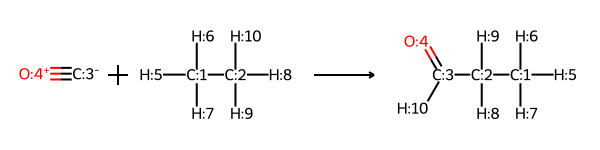

In [3]:
# Load CSV file
csv_file = 'RxnSolvKSE_dataset_v1.1/pretraining_set/chosen_500k_data/pretraining_rxn_solvent_ddGsolv_ddHsolv_500k.csv'
data = pd.read_csv(csv_file)

reaction_smarts = data.iloc[499999, 0]

rxn = rdChemReactions.ReactionFromSmarts(reaction_smarts, useSmiles=True)
rxn

In [ ]:
# Load CSV file
csv_file = '../sample_scripts_for_ML_models/sample_input_file_with_data.csv'
data = pd.read_csv(csv_file)

reaction_smarts = data.iloc[4, 0]

rxn = rdChemReactions.ReactionFromSmarts(reaction_smarts, useSmiles=True)
rxn

IndexError: index 499999 is out of bounds for axis 0 with size 10

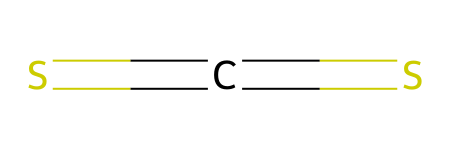

In [21]:
solvent_smarts = data.iloc[0, 1]

mol = Chem.MolFromSmiles(solvent_smarts)
mol

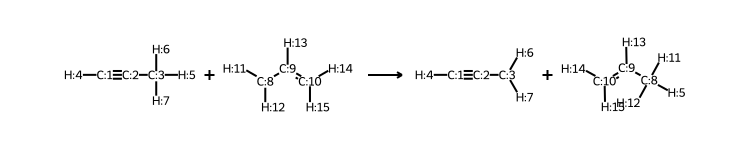

In [12]:
# Load CSV file
csv_file2 = 'RxnSolvKSE_dataset_v1.1/finetuning_set/chosen_data/finetuning_rxn_solvent_ddGsolv_ddHsolv_chosen.csv'
data2 = pd.read_csv(csv_file2)

reaction_smarts2 = data2.iloc[0, 0]

rxn2 = rdChemReactions.ReactionFromSmarts(reaction_smarts2, useSmiles=True)

rxn2

In [14]:
reaction_smarts2 

'[C:1](#[C:2][C:3]([H:5])([H:6])[H:7])[H:4].[C:8]([C:9](=[C:10]([H:14])[H:15])[H:13])([H:11])[H:12]>>[C:1](#[C:2][C:3]([H:6])[H:7])[H:4].[H:5][C:8]([C:9](=[C:10]([H:14])[H:15])[H:13])([H:11])[H:12]'

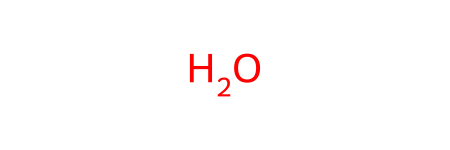

In [4]:
solvent_smarts2 = data2.iloc[0, 1]

mol2 = Chem.MolFromSmiles(solvent_smarts2)
mol2

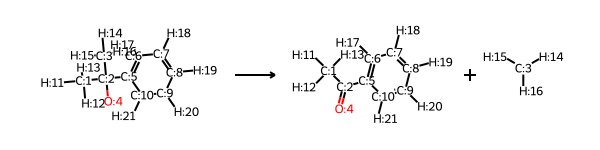

In [17]:
# Load CSV file
csv_file3 = 'RxnSolvKSE_dataset_v1.1/experimental_set/expt_rxn_solv_smiles_with_features_all.csv'
data3 = pd.read_csv(csv_file3)

reaction_smarts3 = data3.iloc[20, 1]

rxn3 = rdChemReactions.ReactionFromSmarts(reaction_smarts3, useSmiles=True)

rxn3

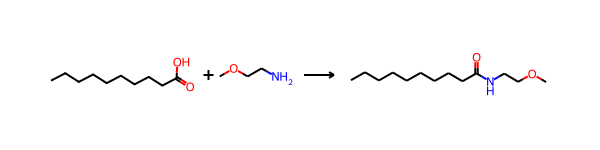

In [10]:
csv_file_amide = 'amide_lnk_data_final.csv'
data_amide = pd.read_csv(csv_file_amide)


reaction_amide = data_amide.iloc[0, 0]

rxn_amide = rdChemReactions.ReactionFromSmarts(reaction_amide, useSmiles=True)

rxn_amide

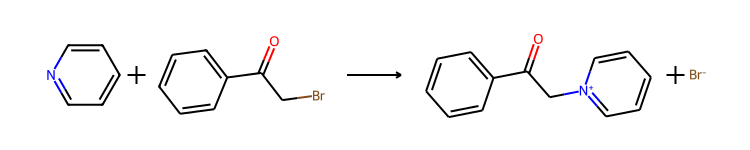

In [9]:
csv_file_menschutkin = 'menschutkin_rxn_solvent_gibbs.csv'
data_menschutkin = pd.read_csv(csv_file_menschutkin)

reaction_menschutkin = data_menschutkin.iloc[0, 0]

rxn_menschutkin = rdChemReactions.ReactionFromSmarts(reaction_menschutkin, useSmiles=True)

rxn_menschutkin

## Make predictions

In [ ]:
# Set the path to the model file and arguments
curr_dir = os.getcwd()
model_dir = os.path.join(curr_dir, '../ML_model_files')

# Set the path to the model file and arguments
arguments = [
    '--test_path', 'rxn_split.csv',
    '--preds_path', 'pred_results_rxn_split.csv',
    '--checkpoint_dir', model_dir,
    '--number_of_molecules', '2',
    '--num_workers', '0',
    '--smiles_columns', 'rxn_smiles', 'solvent_smiles',
    '--empty_cache'
]

In [ ]:
# make predictions
args = chemprop.args.PredictArgs().parse_args(arguments)
preds = chemprop.train.make_predictions(args=args)

In [3]:
df_data = pd.read_csv('rxn_split.csv')
df_pred = pd.read_csv('pred_results_rxn_split.csv')

## Compare the prediction results with the calculated data

In [10]:
# Set the path to the model file and arguments
curr_dir = os.getcwd()
model_dir = os.path.join(curr_dir, '../ML_model_files')

# Set the path to the model file and arguments
arguments = [
    '--test_path', 'rxn_split_fold_0.csv',
    '--preds_path', 'pred_results_rxn_split_fold_0.csv',
    '--checkpoint_dir', model_dir,
    '--number_of_molecules', '2',
    '--num_workers', '0',
    '--uncertainty_method', 'ensemble',
    '--smiles_columns', 'rxn_smiles', 'solvent_smiles',
    '--empty_cache'
]

In [11]:
# make predictions

args = chemprop.args.PredictArgs().parse_args(arguments)
preds = chemprop.train.make_predictions(args=args)

/Users/abdiwadud/miniconda3/envs/chemprop/lib/python3.8/site-packages/chemprop/utils.py:472: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vars(torch.load(path, map_location

Loading training args
Setting molecule featurization parameters to default.
Loading data


24213it [00:00, 113280.79it/s]
100%|██████████| 24213/24213 [00:00<00:00, 150843.86it/s]
[12:02:53] WARNING: not removing hydrogen atom without neighbors


Validating SMILES


[12:02:54] WARNING: not removing hydrogen atom without neighbors


...

Loading pretrained parameter "encoder.encoder.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.W_i.weight".
Loading pretrained parameter "encoder.encoder.W_h.weight".
Loading pretrained parameter "encoder.encoder.W_o.weight".
Loading pretrained parameter "encoder.encoder.W_o.bias".
Loading pretrained parameter "encoder.encoder_solvent.cached_zero_vector".
Loading pretrained parameter "encoder.encoder_solvent.W_i.weight".
Loading pretrained parameter "encoder.encoder_solvent.W_h.weight".
Loading pretrained parameter "encoder.encoder_solvent.W_o.weight".
Loading pretrained parameter "encoder.encoder_solvent.W_o.bias".
Loading pretrained parameter "ffn.1.weight".
Loading pretrained parameter "ffn.1.bias".
Loading pretrained parameter "ffn.4.weight".
Loading pretrained parameter "ffn.4.bias".
Loading pretrained parameter "ffn.7.weight".
Loading pretrained parameter "ffn.7.bias".
Loading pretrained parameter "ffn.10.weight".
Loading pretrained parameter "ffn.10.bias".
Load

  2%|▏         | 3/128 [00:39<27:46, 13.33s/it]

Loading pretrained parameter "encoder.encoder.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.W_i.weight".
Loading pretrained parameter "encoder.encoder.W_h.weight".
Loading pretrained parameter "encoder.encoder.W_o.weight".
Loading pretrained parameter "encoder.encoder.W_o.bias".
Loading pretrained parameter "encoder.encoder_solvent.cached_zero_vector".
Loading pretrained parameter "encoder.encoder_solvent.W_i.weight".
Loading pretrained parameter "encoder.encoder_solvent.W_h.weight".
Loading pretrained parameter "encoder.encoder_solvent.W_o.weight".
Loading pretrained parameter "encoder.encoder_solvent.W_o.bias".
Loading pretrained parameter "ffn.1.weight".
Loading pretrained parameter "ffn.1.bias".
Loading pretrained parameter "ffn.4.weight".
Loading pretrained parameter "ffn.4.bias".
Loading pretrained parameter "ffn.7.weight".
Loading pretrained parameter "ffn.7.bias".
Loading pretrained parameter "ffn.10.weight".
Loading pretrained parameter "ffn.10.bias".
Load

  2%|▏         | 3/128 [00:45<31:55, 15.33s/it]


KeyboardInterrupt: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

In [ ]:
def parity_plot(df_data, df_pred, target_types):
    for target_type in target_types:
        # Set up the figure
        fig = plt.figure(figsize=(6, 5))
        ax = fig.add_subplot(1, 1, 1)

        # Extract true, predicted, and uncertainty values
        true_list_all = df_data[target_type].to_list()
        pred_list_all = df_pred[target_type].to_list()
        uncertainty_list_all = df_pred[f'{target_type}_ensemble_uncal_var'].to_list()  # Load uncertainty values

        # Remove NaN values
        true_list = []
        pred_list = []
        uncertainty_list = []
        for i in range(len(true_list_all)):
            if not pd.isnull(true_list_all[i]):
                true_list.append(true_list_all[i])
                pred_list.append(pred_list_all[i])
                uncertainty_list.append(uncertainty_list_all[i])

        # Create a density plot using a hexbin
        hb = ax.hexbin(
            true_list,
            pred_list,
            gridsize=100,  # Number of bins for hexagonal tiling
            cmap='plasma',  # Use a colormap to represent density
            mincnt=1  # Minimum count to show a bin
        )

        # Add a colorbar to show the density scale
        cb = plt.colorbar(hb, ax=ax)
        cb.set_label('Density', fontsize=15)

        # Add diagonal line x=y
        axmin = min(min(true_list), min(pred_list)) - 0.1 * (max(true_list) - min(pred_list))
        axmax = max(max(true_list), max(pred_list)) + 0.1 * (max(true_list) - min(pred_list))
        ax.plot([axmin, axmax], [axmin, axmax], 'k--', lw=2, label='Ideal Prediction')

        # Set axis labels and title
        ax.set_xlabel(f'Computed {target_type} (kcal/mol)', fontsize=15)
        ax.set_ylabel(f'Predicted {target_type} (kcal/mol)', fontsize=15)
        ax.set_title(f'Hexbin Plot for {target_type}', fontsize=18)

        # Calculate metrics
        R2 = r2_score(true_list, pred_list)
        mae = mean_absolute_error(true_list, pred_list)
        rmse = mean_squared_error(true_list, pred_list, squared=False)

        # Calculate uncertainty for each metric
        R2_uncertainty = np.std([r2_score(true_list, pred_list + np.random.normal(0, np.sqrt(u), len(pred_list))) for u in uncertainty_list])
        mae_uncertainty = np.std([mean_absolute_error(true_list, pred_list + np.random.normal(0, np.sqrt(u), len(pred_list))) for u in uncertainty_list])
        rmse_uncertainty = np.std([mean_squared_error(true_list, pred_list + np.random.normal(0, np.sqrt(u), len(pred_list)), squared=False) for u in uncertainty_list])

        # Add metrics to the plot with uncertainty
        ax.text(0.05, 0.85, f'$R^2$: {R2:.2f} ± {R2_uncertainty:.2f}', transform=ax.transAxes, fontsize=12, verticalalignment='top')
        ax.text(0.05, 0.95, f'MAE: {mae:.2f} ± {mae_uncertainty:.2f}', transform=ax.transAxes, fontsize=12, verticalalignment='top')
        ax.text(0.05, 0.90, f'RMSE: {rmse:.2f} ± {rmse_uncertainty:.2f}', transform=ax.transAxes, fontsize=12, verticalalignment='top')

        # Customize tick font size
        ax.tick_params(axis='both', which='major', labelsize=12)

        # Show plot
        plt.tight_layout()
        plt.show()

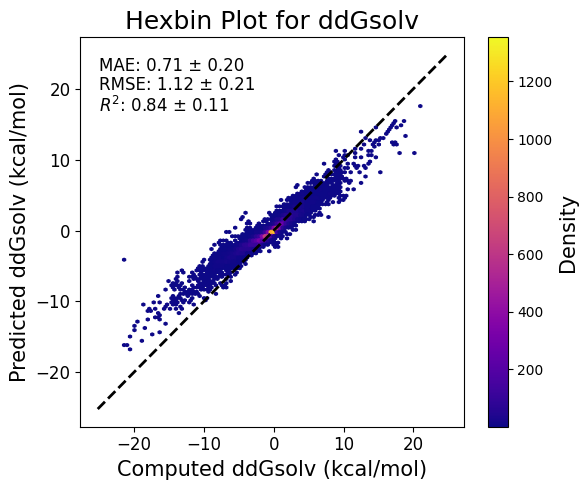

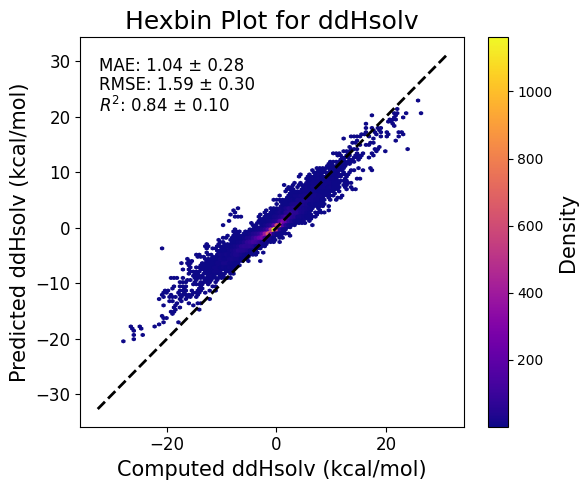

In [ ]:
# Load the data
df_data = pd.read_csv('rxn_split_fold_0.csv')
df_pred = pd.read_csv('pred_results_rxn_split_fold_0_v2.csv')

# List of target columns to plot
target_types = ['ddGsolv', 'ddHsolv']

# Call the function
parity_plot(df_data, df_pred, target_types)

In [ ]:
def error_histogram(pred_data, true_data, target_types):
    for target_type in target_types:
        # Extract predicted and computed values
        predicted_values = pred_data[target_type]
        computed_values = true_data[target_type]

        # Calculate the error
        error = predicted_values - computed_values

        # Create a histogram for the error values
        plt.figure(figsize=(5, 4))
        plt.hist(error, bins=100, density=True, color='blue', edgecolor='black')
        plt.title(f"Histogram of {target_type} Error Probability", fontsize=14)
        plt.xlabel(f"{target_type} Error", fontsize=12)
        plt.ylabel("Probability Density", fontsize=12)
        plt.grid(alpha=0.4)

        # Display the plot
        plt.tight_layout()
        plt.show()

In [ ]:
def predicted_histogram(pred_data, target_types):
    for target_type in target_types:
        # Extract predicted and computed values
        predicted_values = pred_data[target_type]

        # Calculate the error
        error = predicted_values

        # Create a histogram for the error values
        plt.figure(figsize=(5, 4))
        plt.hist(error, bins=40, density=True, color='blue', edgecolor='black')
        plt.title(f"Histogram of {target_type} Probability", fontsize=14)
        plt.xlabel(f"{target_type}", fontsize=12)
        plt.ylabel("Probability Density", fontsize=12)
        plt.grid(alpha=0.4)

        # Display the plot
        plt.tight_layout()
        plt.show()

In [ ]:
def computed_histogram(true_data, target_types):
    for target_type in target_types:
        # Extract predicted and computed values
        computed_values = true_data[target_type]

        # Calculate the error
        error = computed_values

        # Create a histogram for the error values
        plt.figure(figsize=(5, 4))
        plt.hist(error, bins=40, density=True, color='blue', edgecolor='black')
        plt.title(f"Histogram of {target_type} Probability", fontsize=14)
        plt.xlabel(f"{target_type}", fontsize=12)
        plt.ylabel("Probability Density", fontsize=12)
        plt.grid(alpha=0.4)

        # Display the plot
        plt.tight_layout()
        plt.show()

In [ ]:
# Load the data
true_data = pd.read_csv('rxn_split_fold_0.csv')
pred_data = pd.read_csv('pred_results_rxn_split_fold_0_v2.csv')

# List of target columns to plot
target_types = ['ddGsolv', 'ddHsolv']

# Call the function
error_histogram(pred_data, true_data, target_types)

NameError: name 'error_histogram' is not defined

In [ ]:
# Set the path to the model file and arguments
curr_dir = os.getcwd()
model_dir = os.path.join(curr_dir, '../ML_model_files')

# Set the path to the model file and arguments
arguments = [
    '--test_path', 'rxn_split_fold_1.csv',
    '--preds_path', 'pred_results_rxn_split_fold_1_v2.csv',
    '--checkpoint_dir', model_dir,
    '--number_of_molecules', '2',
    '--num_workers', '0',
    '--uncertainty_method', 'ensemble',
    '--smiles_columns', 'rxn_smiles', 'solvent_smiles',
    '--empty_cache'
]

In [ ]:
# make predictions
args = chemprop.args.PredictArgs().parse_args(arguments)
preds = chemprop.train.make_predictions(args=args)

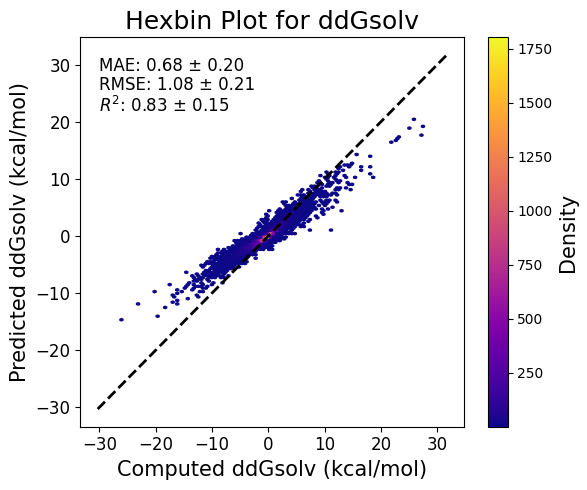

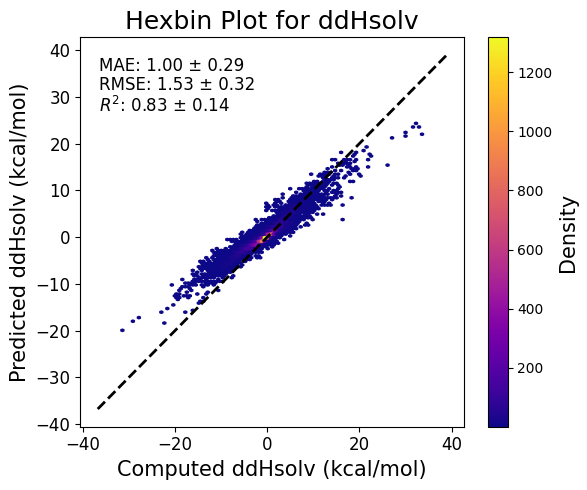

In [ ]:
# Load the data
df_data = pd.read_csv('rxn_split_fold_1.csv')
df_pred = pd.read_csv('pred_results_rxn_split_fold_1_v2.csv')

# List of target columns to plot
target_types = ['ddGsolv', 'ddHsolv']

# Call the function
parity_plot(df_data, df_pred, target_types)

In [ ]:
# Set the path to the model file and arguments
curr_dir = os.getcwd()
model_dir = os.path.join(curr_dir, '../ML_model_files')

# Set the path to the model file and arguments
arguments = [
    '--test_path', 'rxn_split_fold_2.csv',
    '--preds_path', 'pred_results_rxn_split_fold_2_v2.csv',
    '--checkpoint_dir', model_dir,
    '--number_of_molecules', '2',
    '--num_workers', '0',
    '--uncertainty_method', 'ensemble',
    '--smiles_columns', 'rxn_smiles', 'solvent_smiles',
    '--empty_cache'
]

# make predictions
args = chemprop.args.PredictArgs().parse_args(arguments)
preds = chemprop.train.make_predictions(args=args)

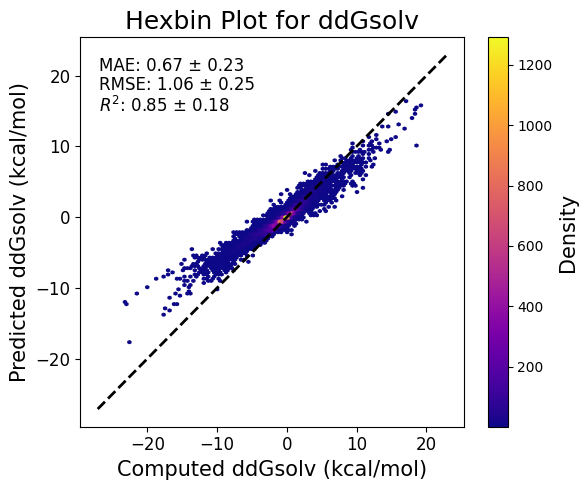

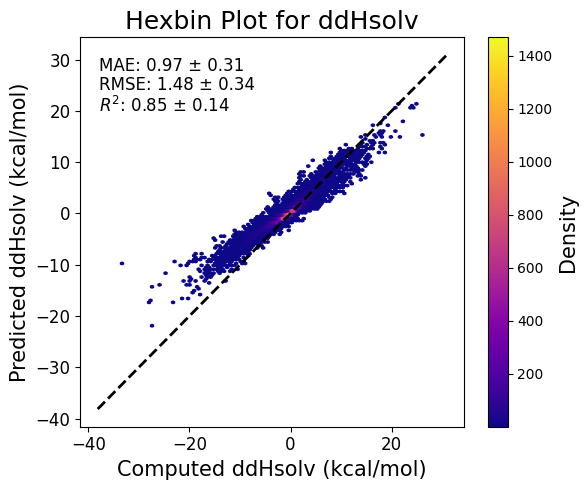

In [ ]:
# Load the data
df_data = pd.read_csv('rxn_split_fold_2.csv')
df_pred = pd.read_csv('pred_results_rxn_split_fold_2_v2.csv')

# List of target columns to plot
target_types = ['ddGsolv', 'ddHsolv']

# Call the function
parity_plot(df_data, df_pred, target_types)

In [ ]:
# Set the path to the model file and arguments
curr_dir = os.getcwd()
model_dir = os.path.join(curr_dir, '../ML_model_files')

# Set the path to the model file and arguments
arguments = [
    '--test_path', 'rxn_split_fold_3.csv',
    '--preds_path', 'pred_results_rxn_split_fold_3_v2.csv',
    '--checkpoint_dir', model_dir,
    '--number_of_molecules', '2',
    '--num_workers', '0',
    '--uncertainty_method', 'ensemble',
    '--smiles_columns', 'rxn_smiles', 'solvent_smiles',
    '--empty_cache'
]
# make predictions

args = chemprop.args.PredictArgs().parse_args(arguments)
preds = chemprop.train.make_predictions(args=args)

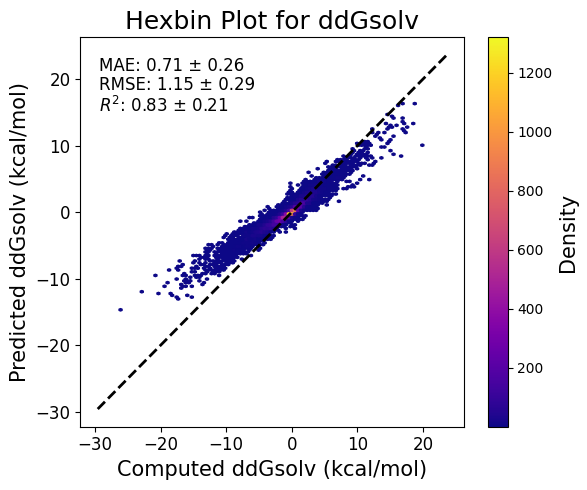

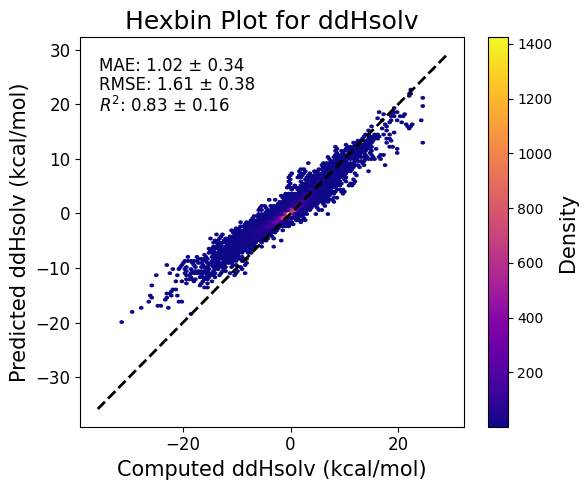

In [ ]:
# Load the data
df_data = pd.read_csv('rxn_split_fold_3.csv')
df_pred = pd.read_csv('pred_results_rxn_split_fold_3_v2.csv')

# List of target columns to plot
target_types = ['ddGsolv', 'ddHsolv']

# Call the function
parity_plot(df_data, df_pred, target_types)

In [ ]:
# Set the path to the model file and arguments
curr_dir = os.getcwd()
model_dir = os.path.join(curr_dir, '../ML_model_files')

# Set the path to the model file and arguments
arguments = [
    '--test_path', 'rxn_split_fold_4.csv',
    '--preds_path', 'pred_results_rxn_split_fold_4_v2.csv',
    '--checkpoint_dir', model_dir,
    '--number_of_molecules', '2',
    '--num_workers', '0',
    '--uncertainty_method', 'ensemble',
    '--smiles_columns', 'rxn_smiles', 'solvent_smiles',
    '--empty_cache'
]
# make predictions

args = chemprop.args.PredictArgs().parse_args(arguments)
preds = chemprop.train.make_predictions(args=args)

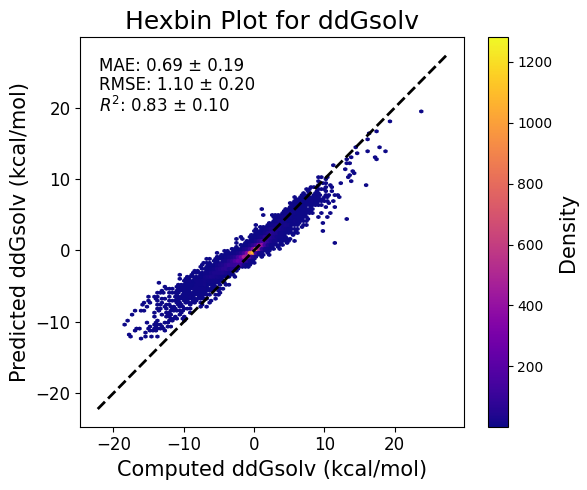

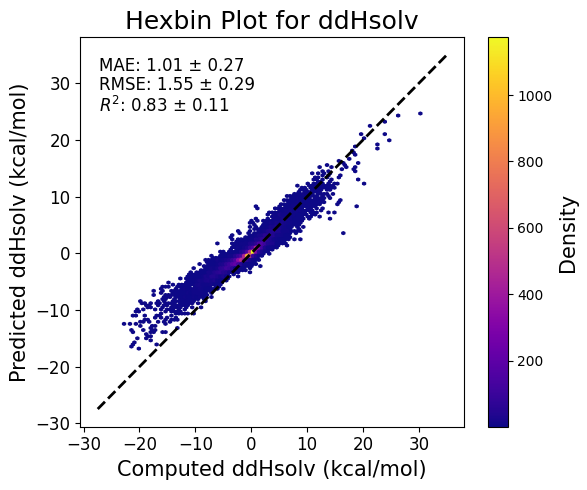

In [ ]:
# Load the data
df_data = pd.read_csv('rxn_split_fold_4.csv')
df_pred = pd.read_csv('pred_results_rxn_split_fold_4_v2.csv')

# List of target columns to plot
target_types = ['ddGsolv', 'ddHsolv']

# Call the function
parity_plot(df_data, df_pred, target_types)

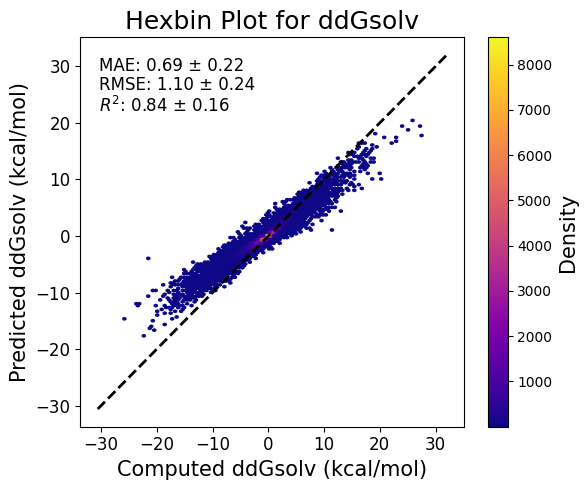

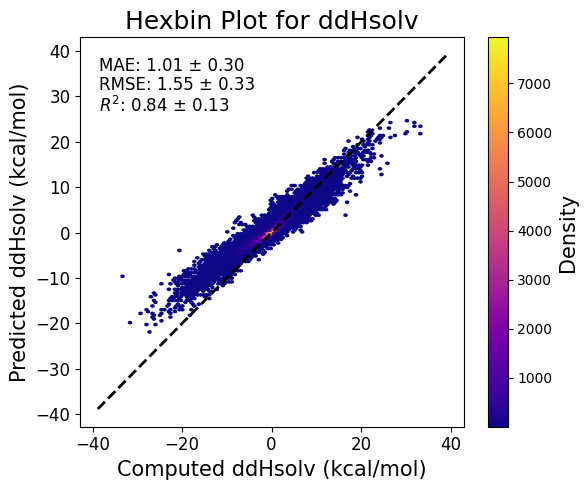

In [ ]:
# Load the data
df_data = pd.read_csv('rxn_split.csv')
df_pred = pd.read_csv('combined_pred_rxn.csv')

# List of target columns to plot
target_types = ['ddGsolv', 'ddHsolv']

# Call the function
parity_plot(df_data, df_pred, target_types)

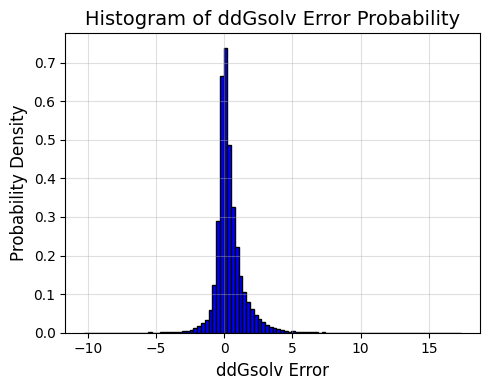

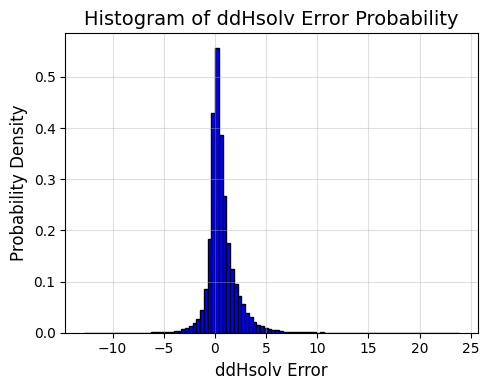

In [ ]:
# Load the data
true_data = pd.read_csv('rxn_split.csv')
pred_data = pd.read_csv('combined_pred_rxn.csv')

# List of target columns to calculate error for
target_types = ['ddGsolv', 'ddHsolv']

# Call the function
error_histogram(pred_data, true_data, target_types)

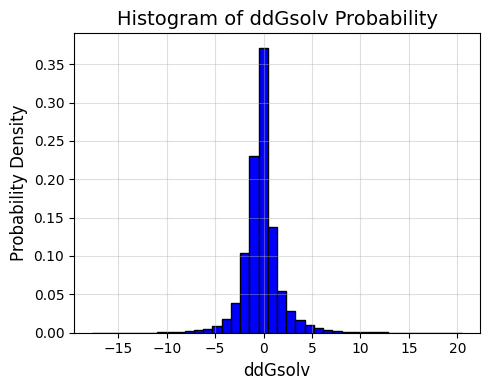

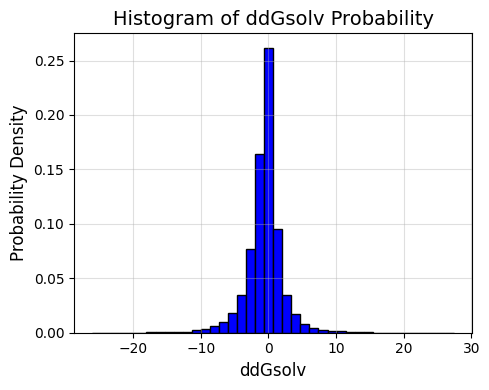

In [ ]:
# Load the data
true_data = pd.read_csv('rxn_split.csv')
pred_data = pd.read_csv('combined_pred_rxn.csv')

# List of target columns to calculate error for
target_types = ['ddGsolv']
predicted_histogram(pred_data, target_types)
computed_histogram(true_data, target_types)

In [ ]:
# Set the path to the model file and arguments
curr_dir = os.getcwd()
model_dir = os.path.join(curr_dir, '../ML_model_files')

# Set the path to the model file and arguments
arguments = [
    '--test_path', 'amide_lnk_data_final.csv',
    '--preds_path', 'pred_results_haas.csv',
    '--checkpoint_dir', model_dir,
    '--number_of_molecules', '2',
    '--num_workers', '0',
    '--smiles_columns', 'ReactionSMILES', 'SolventSMILES',
    '--empty_cache'
]


In [ ]:
# make predictions
args = chemprop.args.PredictArgs().parse_args(arguments)
preds = chemprop.train.make_predictions(args=args)

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def single_parity_plot(df_data, df_pred):
    # Set up the figure
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(1, 1, 1)

    # Extract true and predicted values
    true_list_all = df_data['GIBBS'].to_list()
    pred_list_all = df_pred['ddGsolv'].to_list()

    # Remove NaN values
    true_list = []
    pred_list = []
    for i in range(len(true_list_all)):
        if not pd.isnull(true_list_all[i]):
            true_list.append(true_list_all[i])
            pred_list.append(pred_list_all[i])

    # Create a density plot using a hexbin
    hb = ax.hexbin(
        true_list,
        pred_list,
        gridsize=100,  # Number of bins for hexagonal tiling
        cmap='plasma',  # Use a colormap to represent density
        mincnt=1  # Minimum count to show a bin
    )

    # Add a colorbar to show the density scale
    cb = plt.colorbar(hb, ax=ax)
    cb.set_label('Density', fontsize=15)

    # Add diagonal line x=y
    axmin = min(min(true_list), min(pred_list)) - 0.1 * (max(true_list) - min(pred_list))
    axmax = max(max(true_list), max(pred_list)) + 0.1 * (max(true_list) - min(pred_list))
    ax.plot([axmin, axmax], [axmin, axmax], 'k--', lw=2, label='Ideal Prediction')

    # Set axis labels and title
    ax.set_xlabel('Computed ∆G_reac (kcal/mol)', fontsize=15)
    ax.set_ylabel('Predicted ∆G_reac (kcal/mol)', fontsize=15)
    ax.set_title('Hexbin Plot for ∆G_reac', fontsize=18)

    # Calculate metrics
    R2 = r2_score(true_list, pred_list)
    mae = mean_absolute_error(true_list, pred_list)
    rmse = mean_squared_error(true_list, pred_list, squared=False)

    # Add metrics to the plot
    ax.text(0.05, 0.85, f'$R^2$: {R2:.2f}', transform=ax.transAxes, fontsize=12, verticalalignment='top')
    ax.text(0.05, 0.95, f'MAE: {mae:.2f}', transform=ax.transAxes, fontsize=12, verticalalignment='top')
    ax.text(0.05, 0.90, f'RMSE: {rmse:.2f}', transform=ax.transAxes, fontsize=12, verticalalignment='top')

    # Customize tick font size
    ax.tick_params(axis='both', which='major', labelsize=12)

    # Show plot
    plt.tight_layout()
    plt.show()

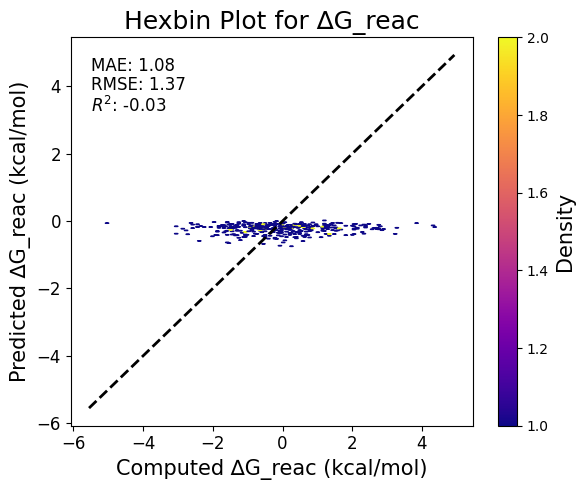

In [11]:
df_data = pd.read_csv('amide_lnk_data_final.csv')
df_pred = pd.read_csv('pred_results_haas.csv')
single_parity_plot(df_data, df_pred)

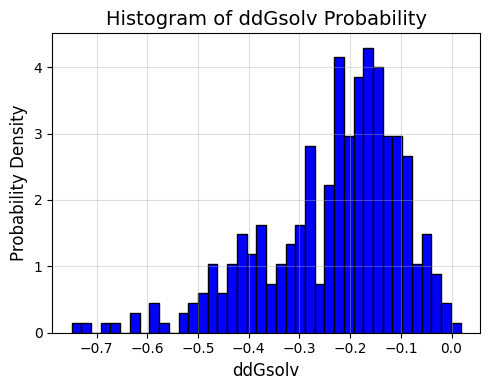

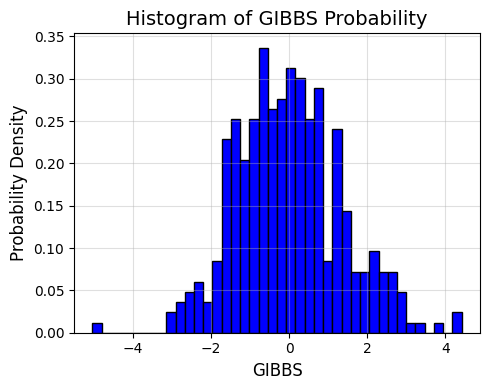

In [ ]:
# Load the data
true_data = pd.read_csv('amide_lnk_data_final.csv')
pred_data = pd.read_csv('pred_results_haas.csv')

predicted_histogram(pred_data, ['ddGsolv'])
computed_histogram(true_data, ['GIBBS'])

In [ ]:
# Set the path to the model file and arguments
curr_dir = os.getcwd()
model_dir = os.path.join(curr_dir, '../ML_model_files')

# Set the path to the model file and arguments
arguments = [
    '--test_path', 'menschutkin_rxn_solvent_gibbs.csv',
    '--preds_path', 'pred_results_men.csv',
    '--checkpoint_dir', model_dir,
    '--number_of_molecules', '2',
    '--num_workers', '0',
    '--smiles_columns', 'RxnSMILES', 'SolventSMILES',
    '--empty_cache'
]

# make predictions
args = chemprop.args.PredictArgs().parse_args(arguments)
preds = chemprop.train.make_predictions(args=args)

/Users/abdiwadud/miniconda3/envs/chemprop/lib/python3.8/site-packages/chemprop/utils.py:472: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vars(torch.load(path, map_location

Loading training args
Setting molecule featurization parameters to default.
Loading data


179it [00:00, 124652.24it/s]
100%|██████████| 179/179 [00:00<00:00, 142166.34it/s]

Validating SMILES


Test size = 179


...

Loading pretrained parameter "encoder.encoder.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.W_i.weight".
Loading pretrained parameter "encoder.encoder.W_h.weight".
Loading pretrained parameter "encoder.encoder.W_o.weight".
Loading pretrained parameter "encoder.encoder.W_o.bias".
Loading pretrained parameter "encoder.encoder_solvent.cached_zero_vector".
Loading pretrained parameter "encoder.encoder_solvent.W_i.weight".
Loading pretrained parameter "encoder.encoder_solvent.W_h.weight".
Loading pretrained parameter "encoder.encoder_solvent.W_o.weight".
Loading pretrained parameter "encoder.encoder_solvent.W_o.bias".
Loading pretrained parameter "ffn.1.weight".
Loading pretrained parameter "ffn.1.bias".
Loading pretrained parameter "ffn.4.weight".
Loading pretrained parameter "ffn.4.bias".
Loading pretrained parameter "ffn.7.weight".
Loading pretrained parameter "ffn.7.bias".
Loading pretrained parameter "ffn.10.weight".
Loading pretrained parameter "ffn.10.bias".
Load

 96%|█████████▌| 24/25 [00:15<00:00,  1.29it/s]

Loading pretrained parameter "encoder.encoder.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.W_i.weight".
Loading pretrained parameter "encoder.encoder.W_h.weight".
Loading pretrained parameter "encoder.encoder.W_o.weight".
Loading pretrained parameter "encoder.encoder.W_o.bias".
Loading pretrained parameter "encoder.encoder_solvent.cached_zero_vector".
Loading pretrained parameter "encoder.encoder_solvent.W_i.weight".
Loading pretrained parameter "encoder.encoder_solvent.W_h.weight".
Loading pretrained parameter "encoder.encoder_solvent.W_o.weight".
Loading pretrained parameter "encoder.encoder_solvent.W_o.bias".
Loading pretrained parameter "ffn.1.weight".
Loading pretrained parameter "ffn.1.bias".
Loading pretrained parameter "ffn.4.weight".
Loading pretrained parameter "ffn.4.bias".
Loading pretrained parameter "ffn.7.weight".
Loading pretrained parameter "ffn.7.bias".
Loading pretrained parameter "ffn.10.weight".
Loading pretrained parameter "ffn.10.bias".
Load

100%|██████████| 25/25 [00:16<00:00,  1.50it/s]

Saving predictions to pred_results_men.csv
Elapsed time = 0:00:17


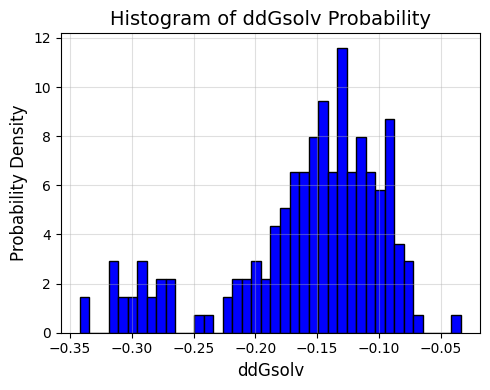

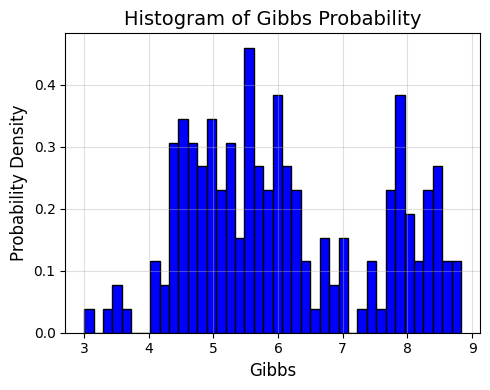

In [ ]:
# Load the data
true_data = pd.read_csv('menschutkin_rxn_solvent_gibbs.csv')
pred_data = pd.read_csv('pred_results_men.csv')

predicted_histogram(pred_data, ['ddGsolv'])
computed_histogram(true_data, ['Gibbs'])

In [ ]:
def box_maker(dataset, Smileset):
    dataset['Weights'] = dataset[Smileset].apply(lambda x: Chem.Descriptors.ExactMolWt(Chem.MolFromSmiles(x)))
    box = dataset.boxplot(column='Weights')


In [ ]:
def molwt_histogram(pred_data, target_types):
    pred_data['Weights'] = pred_data[target_types].apply(lambda x: Chem.Descriptors.Exact
                                                         (Chem.MolFromSmiles(x)))

    # Create a histogram for the error values
    plt.figure(figsize=(5, 4))
    plt.hist(pred_data['Weights'], bins=15, density=True, color='blue', edgecolor='black')
    plt.title(f"Histogram of Molecular Weight", fontsize=14)
    plt.xlabel(f"Molecular Weight (g/mol)", fontsize=12)
    plt.ylabel("Density", fontsize=12)
    plt.grid(alpha=0.4)

    # Display the plot
    plt.tight_layout()
    plt.show()

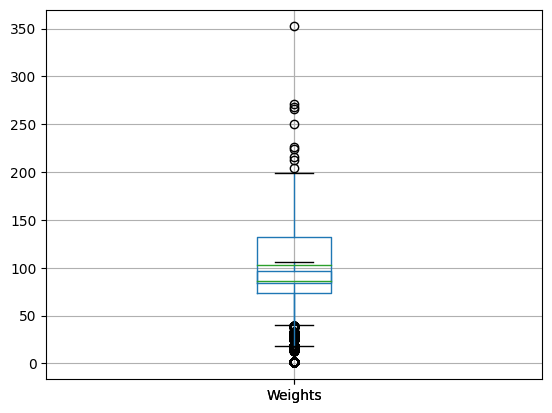

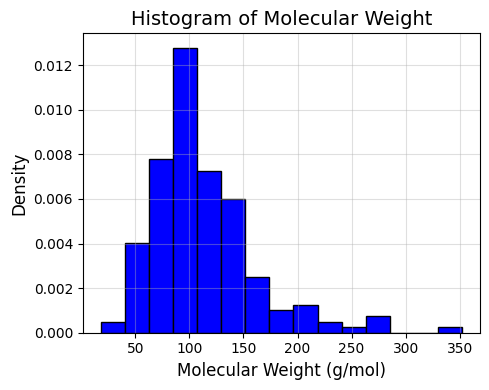

In [ ]:
df_data = pd.read_csv('menschutkin_rxn_solvent_gibbs.csv')
box_maker(df_data,'SolventSMILES')
molwt_histogram(df_data,'SolventSMILES')

[16:06:14] WARNING: not removing hydrogen atom without neighbors
[16:06:14] WARNING: not removing hydrogen atom without neighbors
[16:06:14] WARNING: not removing hydrogen atom without neighbors
[16:06:14] WARNING: not removing hydrogen atom without neighbors
[16:06:14] WARNING: not removing hydrogen atom without neighbors
[16:06:14] WARNING: not removing hydrogen atom without neighbors
[16:06:15] WARNING: not removing hydrogen atom without neighbors
[16:06:15] WARNING: not removing hydrogen atom without neighbors
[16:06:15] WARNING: not removing hydrogen atom without neighbors
[16:06:15] WARNING: not removing hydrogen atom without neighbors
[16:06:15] WARNING: not removing hydrogen atom without neighbors
[16:06:15] WARNING: not removing hydrogen atom without neighbors
[16:06:15] WARNING: not removing hydrogen atom without neighbors
[16:06:15] WARNING: not removing hydrogen atom without neighbors
[16:06:15] WARNING: not removing hydrogen atom without neighbors
[16:06:15] WARNING: not r

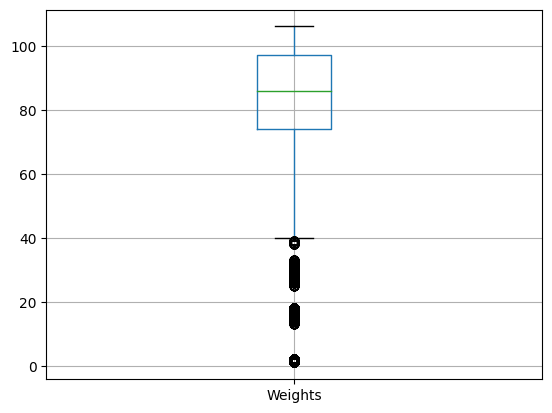

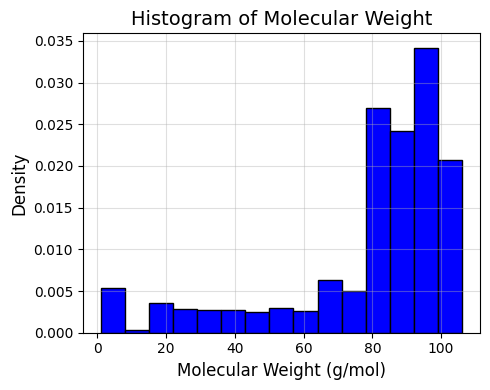

In [ ]:
df_data = pd.read_csv('chung_pretraining_reactants.csv')
box_maker(df_data,'Reactants')
molwt_histogram(df_data,'Reactants')

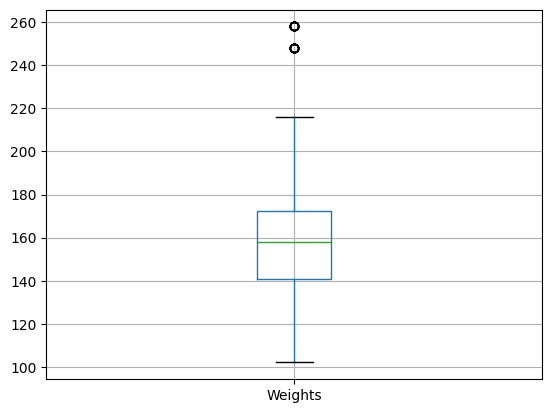

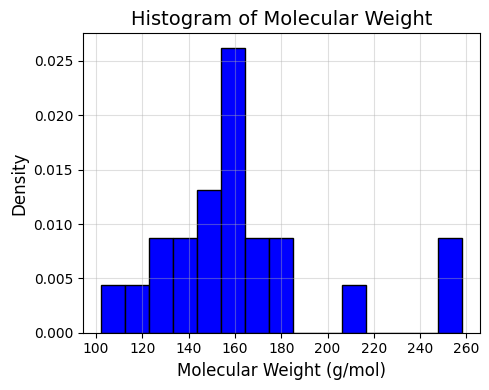

In [ ]:
df_data = pd.read_csv('amide_lnk_data_with_products.csv')
box_maker(df_data,'acidSMILES')
molwt_histogram(df_data,'acidSMILES')

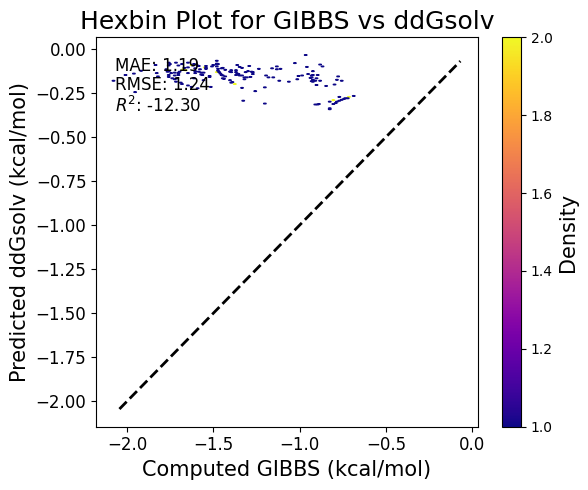

In [ ]:
df_data = pd.read_csv('Menshutkin Gibbs.csv')
df_pred = pd.read_csv('pred_results_men.csv')
single_parity_plot(df_data, df_pred)

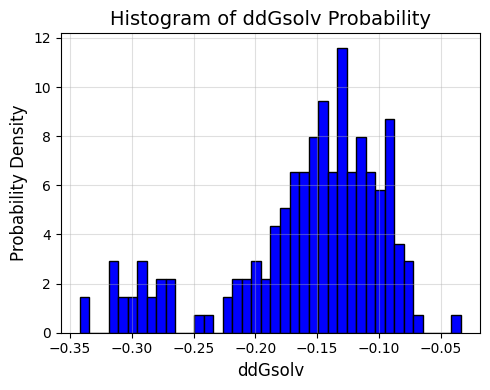

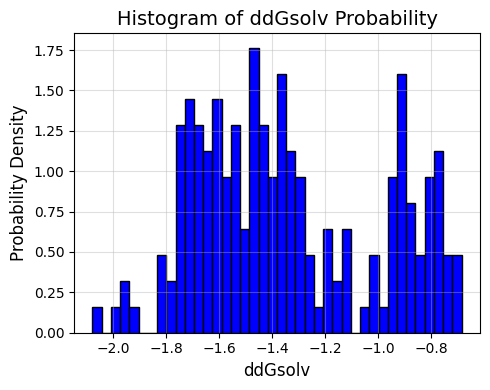

In [ ]:
df_data = pd.read_csv('Menshutkin Gibbs.csv')
df_pred = pd.read_csv('pred_results_men.csv')
target_types = ['ddGsolv']
predicted_histogram(df_pred, target_types)
computed_histogram(df_data, target_types)

In [ ]:
# Set the path to the model file and arguments
curr_dir = os.getcwd()
model_dir = os.path.join(curr_dir, '../ML_model_files')

# Set the path to the model file and arguments
arguments = [
    '--data_path', 'menschutkin_final.csv',
    '--dataset_type', 'regression',
    '--save_dir', 'men_model',
    '--epochs', '2',
    '--checkpoint_paths', 'KSE_ML_model_files/model_0/model.pt',
    'KSE_ML_model_files/model_1/model.pt',
    'KSE_ML_model_files/model_2/model.pt',
    'KSE_ML_model_files/model_3/model.pt',
    'KSE_ML_model_files/model_4/model.pt',
    'KSE_ML_model_files/model_5/model.pt',
    'KSE_ML_model_files/model_6/model.pt',
    'KSE_ML_model_files/model_7/model.pt',
    'KSE_ML_model_files/model_8/model.pt',
    'KSE_ML_model_files/model_9/model.pt',
    'KSE_ML_model_files/model_10/model.pt',
    'KSE_ML_model_files/model_11/model.pt',
    'KSE_ML_model_files/model_12/model.pt',
    'KSE_ML_model_files/model_13/model.pt',
    'KSE_ML_model_files/model_14/model.pt',
    'KSE_ML_model_files/model_15/model.pt',
    'KSE_ML_model_files/model_16/model.pt',
    'KSE_ML_model_files/model_17/model.pt',
    'KSE_ML_model_files/model_18/model.pt',
    'KSE_ML_model_files/model_19/model.pt',
    'KSE_ML_model_files/model_20/model.pt',
    'KSE_ML_model_files/model_21/model.pt',
    'KSE_ML_model_files/model_22/model.pt',
    'KSE_ML_model_files/model_23/model.pt',
    'KSE_ML_model_files/model_24/model.pt',
    '--number_of_molecules', '2',
    '--num_workers', '0',
    '--smiles_columns', 'RxnSMILES', 'SolventSMILES',
    '--empty_cache',
    '--reaction_solvent',
    '--reaction_mode', 'reac_prod',
    '--target_columns', 'ddGsolv',
    '--freeze_first_only',
    '--freeze_encoder',
    '--split_type', 'scaffold_balanced',
    '--split_sizes', '0.8', '0.1', '0.1'
]

# make predictions
args = chemprop.args.TrainArgs().parse_args(arguments)
mean_score, std_score = chemprop.train.cross_validate(args=args, train_func=chemprop.train.run_training)    

usage: ipykernel_launcher.py --data_path DATA_PATH
                             [--target_columns [TARGET_COLUMNS [TARGET_COLUMNS ...]]]
                             [--ignore_columns [IGNORE_COLUMNS [IGNORE_COLUMNS ...]]]
                             --dataset_type
                             {regression,classification,multiclass,spectra}
                             [--loss_function {mse,bounded_mse,binary_cross_entropy,cross_entropy,mcc,sid,wasserstein,mve,evidential,dirichlet,quantile_interval}]
                             [--multiclass_num_classes MULTICLASS_NUM_CLASSES]
                             [--separate_val_path SEPARATE_VAL_PATH]
                             [--separate_test_path SEPARATE_TEST_PATH]
                             [--spectra_phase_mask_path SPECTRA_PHASE_MASK_PATH]
                             [--data_weights_path DATA_WEIGHTS_PATH]
                             [--target_weights [TARGET_WEIGHTS [TARGET_WEIGHTS ...]]]
                             [--split_t

SystemExit: 2

/Users/abdiwadud/miniconda3/envs/chemprop/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3516: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
# Set the path to the model file and arguments
curr_dir = os.getcwd()
model_dir = os.path.join(curr_dir, '../ML_model_files')

# Set the path to the model file and arguments
arguments = [
    '--test_path', 'menschutkin_final.csv',
    '--preds_path', 'pred_results_men_new.csv',
    '--checkpoint_dir', 'men_model/fold_0',
    '--number_of_molecules', '2',
    '--num_workers', '0',
    '--smiles_columns', 'RxnSMILES', 'SolventSMILES',
    '--empty_cache',
]

# make predictions
args = chemprop.args.PredictArgs().parse_args(arguments)
preds = chemprop.train.make_predictions(args=args)

usage: ipykernel_launcher.py --test_path TEST_PATH --preds_path PREDS_PATH
                             [--drop_extra_columns] [--ensemble_variance]
                             [--individual_ensemble_predictions]
                             [--uncertainty_method {mve,ensemble,evidential_epistemic,evidential_aleatoric,evidential_total,classification,dropout,spectra_roundrobin,dirichlet}]
                             [--calibration_method {zscaling,tscaling,zelikman_interval,mve_weighting,platt,isotonic,conformal,conformal_adaptive,conformal_regression,conformal_quantile_regression}]
                             [--evaluation_methods [EVALUATION_METHODS [EVALUATION_METHODS ...]]]
                             [--evaluation_scores_path EVALUATION_SCORES_PATH]
                             [--uncertainty_dropout_p UNCERTAINTY_DROPOUT_P]
                             [--conformal_alpha CONFORMAL_ALPHA]
                             [--dropout_sampling_size DROPOUT_SAMPLING_SIZE]
             

SystemExit: 2

/Users/abdiwadud/miniconda3/envs/chemprop/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3516: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


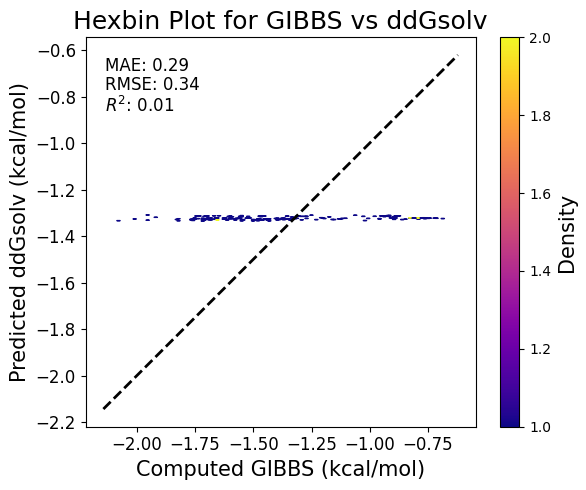

In [ ]:
df_data = pd.read_csv('menschutkin_final.csv')
df_pred = pd.read_csv('pred_results_men_new.csv')

single_parity_plot(df_data, df_pred)

In [ ]:
# Set the path to the model file and arguments
curr_dir = os.getcwd()
model_dir = os.path.join(curr_dir, '../ML_model_files')

# Set the path to the model file and arguments
arguments = [
    '--data_path', 'amide_lnk_data_final.csv',
    '--dataset_type', 'regression',
    '--save_dir', 'haas_model',
    '--epochs', '5',
    '--checkpoint_paths', 'KSE_ML_model_files/model_0/model.pt',
    'KSE_ML_model_files/model_1/model.pt',
    'KSE_ML_model_files/model_2/model.pt',
    'KSE_ML_model_files/model_3/model.pt',
    'KSE_ML_model_files/model_4/model.pt',
    'KSE_ML_model_files/model_5/model.pt',
    'KSE_ML_model_files/model_6/model.pt',
    'KSE_ML_model_files/model_7/model.pt',
    'KSE_ML_model_files/model_8/model.pt',
    'KSE_ML_model_files/model_9/model.pt',
    'KSE_ML_model_files/model_10/model.pt',
    'KSE_ML_model_files/model_11/model.pt',
    'KSE_ML_model_files/model_12/model.pt',
    'KSE_ML_model_files/model_13/model.pt',
    'KSE_ML_model_files/model_14/model.pt',
    'KSE_ML_model_files/model_15/model.pt',
    'KSE_ML_model_files/model_16/model.pt',
    'KSE_ML_model_files/model_17/model.pt',
    'KSE_ML_model_files/model_18/model.pt',
    'KSE_ML_model_files/model_19/model.pt',
    'KSE_ML_model_files/model_20/model.pt',
    'KSE_ML_model_files/model_21/model.pt',
    'KSE_ML_model_files/model_22/model.pt',
    'KSE_ML_model_files/model_23/model.pt',
    'KSE_ML_model_files/model_24/model.pt',
    '--number_of_molecules', '2',
    '--num_workers', '0',
    '--smiles_columns', 'ReactionSMILES', 'SolventSMILES',
    '--empty_cache',
    '--reaction_solvent',
    '--reaction_mode', 'reac_prod',
    '--target_columns', 'GIBBS',
    '--split_type', 'scaffold_balanced',
    '--split_sizes', '0.8', '0.1', '0.1'
]

# make predictions
args = chemprop.args.TrainArgs().parse_args(arguments)
mean_score, std_score = chemprop.train.cross_validate(args=args, train_func=chemprop.train.run_training)   

Command line
python /Users/abdiwadud/miniconda3/envs/chemprop/lib/python3.8/site-packages/ipykernel_launcher.py --f=/Users/abdiwadud/Library/Jupyter/runtime/kernel-v3ac7cb069cd8377663bf5f3557b3d634f3a05ff4c.json
Args
{'activation': 'ReLU',
 'adding_bond_types': True,
 'adding_h': False,
 'aggregation': 'mean',
 'aggregation_norm': 100,
 'atom_constraints': [],
 'atom_descriptor_scaling': True,
 'atom_descriptors': None,
 'atom_descriptors_path': None,
 'atom_descriptors_size': 0,
 'atom_features_size': 0,
 'atom_messages': False,
 'atom_targets': [],
 'batch_size': 50,
 'bias': False,
 'bias_solvent': False,
 'bond_constraints': [],
 'bond_descriptor_scaling': True,
 'bond_descriptors': None,
 'bond_descriptors_path': None,
 'bond_descriptors_size': 0,
 'bond_features_size': 0,
 'bond_targets': [],
 'cache_cutoff': 10000,
 'checkpoint_dir': None,
 'checkpoint_frzn': None,
 'checkpoint_path': None,
 'checkpoint_paths': ['KSE_ML_model_files/model_0/model.pt',
                      'KSE_M

In [ ]:
# Set the path to the model file and arguments
curr_dir = os.getcwd()
model_dir = os.path.join(curr_dir, '../ML_model_files')

# Set the path to the model file and arguments
arguments = [
    '--test_path', 'amide_lnk_data_final.csv',
    '--preds_path', 'pred_results_haas_new.csv',
    '--checkpoint_dir', 'haas_model/fold_0',
    '--number_of_molecules', '2',
    '--num_workers', '0',
    '--smiles_columns', 'ReactionSMILES', 'SolventSMILES',
    '--empty_cache',
]

# make predictions
args = chemprop.args.PredictArgs().parse_args(arguments)
preds = chemprop.train.make_predictions(args=args)

/Users/abdiwadud/miniconda3/envs/chemprop/lib/python3.8/site-packages/chemprop/utils.py:472: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vars(torch.load(path, map_location

Loading training args
Setting molecule featurization parameters to default.
Loading data


352it [00:00, 251772.68it/s]
100%|██████████| 352/352 [00:00<00:00, 281378.88it/s]

Validating SMILES


Test size = 352


...

 88%|████████▊ | 22/25 [00:15<00:01,  1.54it/s]

 92%|█████████▏| 23/25 [00:15<00:01,  1.57it/s]

 96%|█████████▌| 24/25 [00:16<00:00,  1.59it/s]

100%|██████████| 25/25 [00:16<00:00,  1.48it/s]

Saving predictions to pred_results_haas_new.csv
Elapsed time = 0:00:18


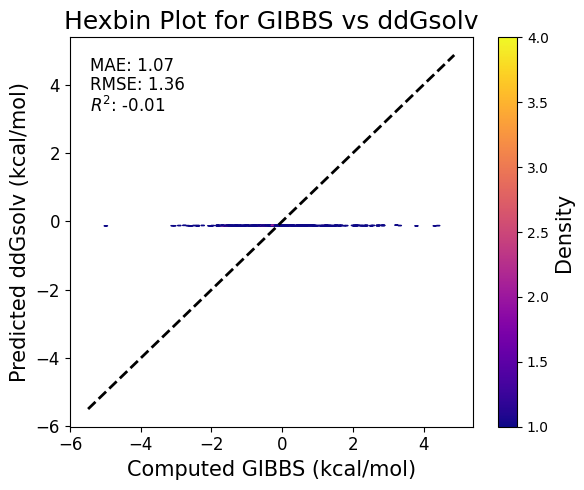

In [ ]:
df_data = pd.read_csv('amide_lnk_data_final.csv')
df_pred = pd.read_csv('pred_results_haas_new.csv')

single_parity_plot(df_data, df_pred)

In [ ]:
# Set the path to the model file and arguments
curr_dir = os.getcwd()
model_dir = os.path.join(curr_dir, '../ML_model_files')

# Set the path to the model file and arguments
arguments = [
    '--data_path', 'menschutkin_final.csv',
    '--dataset_type', 'regression',
    '--save_dir', 'men_model',
    '--epochs', '5',
    '--checkpoint_paths', 'KSE_ML_model_files/model_0/model.pt',
    '--number_of_molecules', '2',
    '--num_workers', '0',
    '--smiles_columns', 'RxnSMILES', 'SolventSMILES',
    '--empty_cache',
    '--reaction_solvent',
    '--reaction_mode', 'reac_prod',
    '--target_columns', 'ddGsolv',
]

# make predictions
args = chemprop.args.TrainArgs().parse_args(arguments)
mean_score, std_score = chemprop.train.cross_validate(args=args, train_func=chemprop.train.run_training)    

Command line
python /Users/abdiwadud/miniconda3/envs/chemprop/lib/python3.8/site-packages/ipykernel_launcher.py --f=/Users/abdiwadud/Library/Jupyter/runtime/kernel-v36eda71d910a6d68a13a2dfde7173a9c0a3212a8b.json
Args
{'activation': 'ReLU',
 'adding_bond_types': True,
 'adding_h': False,
 'aggregation': 'mean',
 'aggregation_norm': 100,
 'atom_constraints': [],
 'atom_descriptor_scaling': True,
 'atom_descriptors': None,
 'atom_descriptors_path': None,
 'atom_descriptors_size': 0,
 'atom_features_size': 0,
 'atom_messages': False,
 'atom_targets': [],
 'batch_size': 50,
 'bias': False,
 'bias_solvent': False,
 'bond_constraints': [],
 'bond_descriptor_scaling': True,
 'bond_descriptors': None,
 'bond_descriptors_path': None,
 'bond_descriptors_size': 0,
 'bond_features_size': 0,
 'bond_targets': [],
 'cache_cutoff': 10000,
 'checkpoint_dir': None,
 'checkpoint_frzn': None,
 'checkpoint_path': None,
 'checkpoint_paths': ['KSE_ML_model_files/model_0/model.pt'],
 'class_balance': False,
 '

In [ ]:
curr_dir = os.getcwd()
model_dir = os.path.join(curr_dir, '../ML_model_files')

# Set the path to the model file and arguments
arguments = [
    '--data_path', 'menschutkin_final.csv',
    '--dataset_type', 'regression',
    '--save_dir', 'men_model',
    '--epochs', '10',
    '--checkpoint_frzn', 'KSE_ML_model_files/model_0/model.pt',
    
    '--number_of_molecules', '2',
    '--num_workers', '0',
    '--smiles_columns', 'RxnSMILES', 'SolventSMILES',
    '--empty_cache',
    '--reaction_solvent',
    '--reaction_mode', 'reac_prod',
    '--target_columns', 'ddGsolv',
]

# make predictions
args = chemprop.args.TrainArgs().parse_args(arguments)
mean_score, std_score = chemprop.train.cross_validate(args=args, train_func=chemprop.train.run_training)   

Command line
python /Users/abdiwadud/miniconda3/envs/chemprop/lib/python3.8/site-packages/ipykernel_launcher.py --f=/Users/abdiwadud/Library/Jupyter/runtime/kernel-v36ac185d4b3aa7b92082aec9a3cf198eac6020286.json
Args
{'activation': 'ReLU',
 'adding_bond_types': True,
 'adding_h': False,
 'aggregation': 'mean',
 'aggregation_norm': 100,
 'atom_constraints': [],
 'atom_descriptor_scaling': True,
 'atom_descriptors': None,
 'atom_descriptors_path': None,
 'atom_descriptors_size': 0,
 'atom_features_size': 0,
 'atom_messages': False,
 'atom_targets': [],
 'batch_size': 50,
 'bias': False,
 'bias_solvent': False,
 'bond_constraints': [],
 'bond_descriptor_scaling': True,
 'bond_descriptors': None,
 'bond_descriptors_path': None,
 'bond_descriptors_size': 0,
 'bond_features_size': 0,
 'bond_targets': [],
 'cache_cutoff': 10000,
 'checkpoint_dir': None,
 'checkpoint_frzn': 'KSE_ML_model_files/model_0/model.pt',
 'checkpoint_path': None,
 'checkpoint_paths': None,
 'class_balance': False,
 'co

Pretrained parameter "('encoder.encoder.0.W_i.weight', 'encoder.encoder.0.W_h.weight', 'encoder.encoder.0.W_o.weight', 'encoder.encoder.0.W_o.bias')" cannot be found in model parameters.
Pretrained parameter "('encoder.encoder.1.W_i.weight', 'encoder.encoder.1.W_h.weight', 'encoder.encoder.1.W_o.weight', 'encoder.encoder.1.W_o.bias')" cannot be found in model parameters.


  0%|          | 0/10 [00:00<?, ?it/s]Epoch 0
Validation rmse = 0.446928
 10%|█         | 1/10 [00:00<00:04,  2.24it/s]Epoch 1
Validation rmse = 0.430881
 20%|██        | 2/10 [00:00<00:02,  2.85it/s]Epoch 2
Validation rmse = 0.420680
 30%|███       | 3/10 [00:01<00:02,  3.16it/s]Epoch 3
Loss = 9.6122e-01, PNorm = 46.3585, GNorm = 2.2819, lr_0 = 3.1623e-04
Validation rmse = 0.424159
 40%|████      | 4/10 [00:01<00:01,  3.33it/s]Epoch 4
Validation rmse = 0.430296
 50%|█████     | 5/10 [00:01<00:01,  3.44it/s]Epoch 5
Validation rmse = 0.427722
 60%|██████    | 6/10 [00:01<00:01,  3.37it/s]Epoch 6
Loss = 8.4960e-01, PNorm = 46.3611, GNorm = 0.7844, lr_0 = 1.0000e-04
Validation rmse = 0.425613
 70%|███████   | 7/10 [00:02<00:00,  3.33it/s]Epoch 7
Validation rmse = 0.423149
 80%|████████  | 8/10 [00:02<00:00,  3.09it/s]Epoch 8
Validation rmse = 0.420576
 90%|█████████ | 9/10 [00:02<00:00,  3.23it/s]Epoch 9
Validation rmse = 0.419074
100%|██████████| 10/10 [00:03<00:00,  3.19it/s]
Model 0 be

In [ ]:
# Set the path to the model file and arguments
curr_dir = os.getcwd()
model_dir = os.path.join(curr_dir, '../ML_model_files')

# Set the path to the model file and arguments
arguments = [
    '--test_path', 'menschutkin_final.csv',
    '--preds_path', 'pred_results_men_new.csv',
    '--checkpoint_dir', 'men_model/fold_0',
    '--number_of_molecules', '2',
    '--num_workers', '0',
    '--smiles_columns', 'RxnSMILES', 'SolventSMILES',
    '--empty_cache',
]

# make predictions
args = chemprop.args.PredictArgs().parse_args(arguments)
preds = chemprop.train.make_predictions(args=args)

/Users/abdiwadud/miniconda3/envs/chemprop/lib/python3.8/site-packages/chemprop/utils.py:472: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vars(torch.load(path, map_location

Loading training args
Setting molecule featurization parameters to default.
Loading data


179it [00:00, 243522.68it/s]
100%|██████████| 179/179 [00:00<00:00, 257469.28it/s]

Validating SMILES


Test size = 179


...

 88%|████████▊ | 22/25 [00:09<00:01,  2.45it/s]

 92%|█████████▏| 23/25 [00:09<00:00,  2.46it/s]

 96%|█████████▌| 24/25 [00:09<00:00,  2.26it/s]

100%|██████████| 25/25 [00:10<00:00,  2.40it/s]

Saving predictions to pred_results_men_new.csv
Elapsed time = 0:00:11


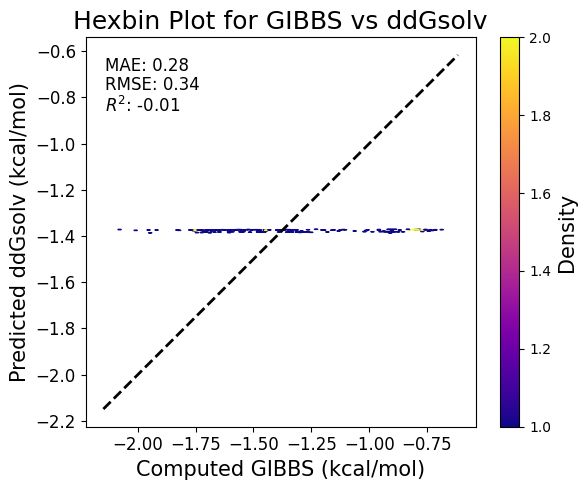

In [ ]:
df_data = pd.read_csv('menschutkin_final.csv')
df_pred = pd.read_csv('pred_results_men_new.csv')

single_parity_plot(df_data, df_pred)

In [ ]:
# Set the path to the model file and arguments
curr_dir = os.getcwd()
model_dir = os.path.join(curr_dir, '../ML_model_files')

# Set the path to the model file and arguments
arguments = [
    '--data_path', 'menschutkin_final.csv',
    '--dataset_type', 'regression',
    '--save_dir', 'men_model_corrected',
    '--epochs', '10',
    '--checkpoint_paths', 'KSE_ML_model_files/model_0/model.pt',
    'KSE_ML_model_files/model_1/model.pt',
    'KSE_ML_model_files/model_2/model.pt',
    'KSE_ML_model_files/model_3/model.pt',
    'KSE_ML_model_files/model_4/model.pt',
    'KSE_ML_model_files/model_5/model.pt',
    'KSE_ML_model_files/model_6/model.pt',
    'KSE_ML_model_files/model_7/model.pt',
    'KSE_ML_model_files/model_8/model.pt',
    'KSE_ML_model_files/model_9/model.pt',
    'KSE_ML_model_files/model_10/model.pt',
    'KSE_ML_model_files/model_11/model.pt',
    'KSE_ML_model_files/model_12/model.pt',
    'KSE_ML_model_files/model_13/model.pt',
    'KSE_ML_model_files/model_14/model.pt',
    'KSE_ML_model_files/model_15/model.pt',
    'KSE_ML_model_files/model_16/model.pt',
    'KSE_ML_model_files/model_17/model.pt',
    'KSE_ML_model_files/model_18/model.pt',
    'KSE_ML_model_files/model_19/model.pt',
    'KSE_ML_model_files/model_20/model.pt',
    'KSE_ML_model_files/model_21/model.pt',
    'KSE_ML_model_files/model_22/model.pt',
    'KSE_ML_model_files/model_23/model.pt',
    'KSE_ML_model_files/model_24/model.pt',
    '--number_of_molecules', '2',
    '--num_workers', '0',
    '--smiles_columns', 'RxnSMILES', 'SolventSMILES',
    '--empty_cache',
    '--reaction_solvent',
    '--reaction_mode', 'reac_prod',
    '--target_columns', 'ddGsolv',
]

# make predictions
args = chemprop.args.TrainArgs().parse_args(arguments)
mean_score, std_score = chemprop.train.cross_validate(args=args, train_func=chemprop.train.run_training)   

Command line
python /Users/abdiwadud/miniconda3/envs/chemprop/lib/python3.8/site-packages/ipykernel_launcher.py --f=/Users/abdiwadud/Library/Jupyter/runtime/kernel-v3ac7cb069cd8377663bf5f3557b3d634f3a05ff4c.json
Args
{'activation': 'ReLU',
 'adding_bond_types': True,
 'adding_h': False,
 'aggregation': 'mean',
 'aggregation_norm': 100,
 'atom_constraints': [],
 'atom_descriptor_scaling': True,
 'atom_descriptors': None,
 'atom_descriptors_path': None,
 'atom_descriptors_size': 0,
 'atom_features_size': 0,
 'atom_messages': False,
 'atom_targets': [],
 'batch_size': 50,
 'bias': False,
 'bias_solvent': False,
 'bond_constraints': [],
 'bond_descriptor_scaling': True,
 'bond_descriptors': None,
 'bond_descriptors_path': None,
 'bond_descriptors_size': 0,
 'bond_features_size': 0,
 'bond_targets': [],
 'cache_cutoff': 10000,
 'checkpoint_dir': None,
 'checkpoint_frzn': None,
 'checkpoint_path': None,
 'checkpoint_paths': ['KSE_ML_model_files/model_0/model.pt',
                      'KSE_M

In [ ]:
# Set the path to the model file and arguments
curr_dir = os.getcwd()
model_dir = os.path.join(curr_dir, '../ML_model_files')

# Set the path to the model file and arguments
arguments = [
    '--test_path', 'menschutkin_final.csv',
    '--preds_path', 'pred_results_men_corrected.csv',
    '--checkpoint_dir', 'men_model/fold_0',
    '--number_of_molecules', '2',
    '--num_workers', '0',
    '--smiles_columns', 'RxnSMILES', 'SolventSMILES',
    '--empty_cache',
]

# make predictions
args = chemprop.args.PredictArgs().parse_args(arguments)
preds = chemprop.train.make_predictions(args=args)

/Users/abdiwadud/miniconda3/envs/chemprop/lib/python3.8/site-packages/chemprop/utils.py:472: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vars(torch.load(path, map_location

Loading training args
Setting molecule featurization parameters to default.
Loading data


179it [00:00, 260597.16it/s]
100%|██████████| 179/179 [00:00<00:00, 269096.92it/s]

Validating SMILES


Test size = 179


...

 88%|████████▊ | 22/25 [00:07<00:01,  2.90it/s]

 92%|█████████▏| 23/25 [00:07<00:00,  2.91it/s]

 96%|█████████▌| 24/25 [00:08<00:00,  2.91it/s]

100%|██████████| 25/25 [00:08<00:00,  2.92it/s]

Saving predictions to pred_results_men_corrected.csv
Elapsed time = 0:00:09


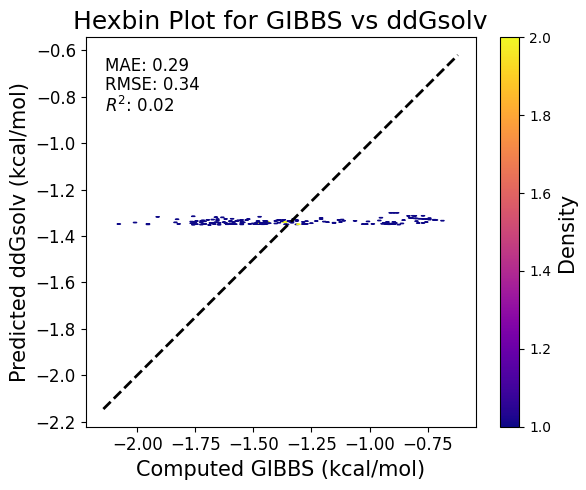

In [ ]:
df_data = pd.read_csv('menschutkin_final.csv')
df_pred = pd.read_csv('pred_results_men_corrected.csv')

single_parity_plot(df_data, df_pred)

RE FINETUNE MODEL

In [ ]:
# Set the path to the model file and arguments
curr_dir = os.getcwd()
model_dir = os.path.join(curr_dir, '../ML_model_files')

# Set the path to the model file and arguments
arguments = [
    '--data_path', 'RxnSolvKSE_dataset_v1.1/finetuning_set/chosen_data/finetuning_rxn_solvent_ddGsolv_ddHsolv_chosen.csv',
    '--dataset_type', 'regression',
    '--save_dir', 'refinetuned_models',
    '--epochs', '5',
    '--checkpoint_paths', 'KSE_ML_model_files/model_0/model.pt',
    'KSE_ML_model_files/model_1/model.pt',
    'KSE_ML_model_files/model_2/model.pt',
    'KSE_ML_model_files/model_3/model.pt',
    'KSE_ML_model_files/model_4/model.pt',
    'KSE_ML_model_files/model_5/model.pt',
    'KSE_ML_model_files/model_6/model.pt',
    'KSE_ML_model_files/model_7/model.pt',
    'KSE_ML_model_files/model_8/model.pt',
    'KSE_ML_model_files/model_9/model.pt',
    'KSE_ML_model_files/model_10/model.pt',
    'KSE_ML_model_files/model_11/model.pt',
    'KSE_ML_model_files/model_12/model.pt',
    'KSE_ML_model_files/model_13/model.pt',
    'KSE_ML_model_files/model_14/model.pt',
    'KSE_ML_model_files/model_15/model.pt',
    'KSE_ML_model_files/model_16/model.pt',
    'KSE_ML_model_files/model_17/model.pt',
    'KSE_ML_model_files/model_18/model.pt',
    'KSE_ML_model_files/model_19/model.pt',
    'KSE_ML_model_files/model_20/model.pt',
    'KSE_ML_model_files/model_21/model.pt',
    'KSE_ML_model_files/model_22/model.pt',
    'KSE_ML_model_files/model_23/model.pt',
    'KSE_ML_model_files/model_24/model.pt',
    '--number_of_molecules', '2',
    '--num_workers', '0',
    '--smiles_columns', 'rxn_smiles', 'solvent_smiles',
    '--empty_cache',
    '--reaction_solvent',
    '--reaction_mode', 'reac_prod',
    '--target_columns', 'ddGsolv'
]

# make predictions
args = chemprop.args.TrainArgs().parse_args(arguments)
mean_score, std_score = chemprop.train.cross_validate(args=args, train_func=chemprop.train.run_training)

Command line
python /Users/abdiwadud/miniconda3/envs/chemprop/lib/python3.8/site-packages/ipykernel_launcher.py --f=/Users/abdiwadud/Library/Jupyter/runtime/kernel-v3ac7cb069cd8377663bf5f3557b3d634f3a05ff4c.json
Args
{'activation': 'ReLU',
 'adding_bond_types': True,
 'adding_h': False,
 'aggregation': 'mean',
 'aggregation_norm': 100,
 'atom_constraints': [],
 'atom_descriptor_scaling': True,
 'atom_descriptors': None,
 'atom_descriptors_path': None,
 'atom_descriptors_size': 0,
 'atom_features_size': 0,
 'atom_messages': False,
 'atom_targets': [],
 'batch_size': 50,
 'bias': False,
 'bias_solvent': False,
 'bond_constraints': [],
 'bond_descriptor_scaling': True,
 'bond_descriptors': None,
 'bond_descriptors_path': None,
 'bond_descriptors_size': 0,
 'bond_features_size': 0,
 'bond_targets': [],
 'cache_cutoff': 10000,
 'checkpoint_dir': None,
 'checkpoint_frzn': None,
 'checkpoint_path': None,
 'checkpoint_paths': ['KSE_ML_model_files/model_0/model.pt',
                      'KSE_M

In [ ]:
# Set the path to the model file and arguments
curr_dir = os.getcwd()
model_dir = os.path.join(curr_dir, '../ML_model_files')

# Set the path to the model file and arguments
arguments = [
    '--test_path', 'rxn_split_fold_0.csv',
    '--preds_path', 'pred_results_rxn_split_fold_0.csv',
    '--checkpoint_dir', 'refinetuned_models/fold_0',
    '--number_of_molecules', '2',
    '--num_workers', '0',
    '--uncertainty_method', 'ensemble',
    '--smiles_columns', 'rxn_smiles', 'solvent_smiles',
    '--empty_cache'
]

# make predictions
args = chemprop.args.PredictArgs().parse_args(arguments)
preds = chemprop.train.make_predictions(args=args)

/Users/abdiwadud/miniconda3/envs/chemprop/lib/python3.8/site-packages/chemprop/utils.py:472: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vars(torch.load(path, map_location

Loading training args
Setting molecule featurization parameters to default.
Loading data


24213it [00:00, 156850.35it/s]
100%|██████████| 24213/24213 [00:00<00:00, 158721.75it/s]
[11:20:51] WARNING: not removing hydrogen atom without neighbors
[11:20:52] WARNING: not removing hydrogen atom without neighbors


Validating SMILES
Test size = 24,213


  0%|          | 0/25 [00:00<?, ?it/s]/Users/abdiwadud/miniconda3/envs/chemprop/lib/python3.8/site-packages/chemprop/utils.py:111: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature

...

 88%|████████▊ | 22/25 [04:16<00:35, 11.86s/it]

 92%|█████████▏| 23/25 [04:28<00:23, 11.86s/it]

 96%|█████████▌| 24/25 [04:40<00:11, 11.97s/it]

100%|██████████| 25/25 [04:53<00:00, 11.73s/it]


Saving predictions to pred_results_rxn_split_fold_0.csv
Elapsed time = 0:04:56


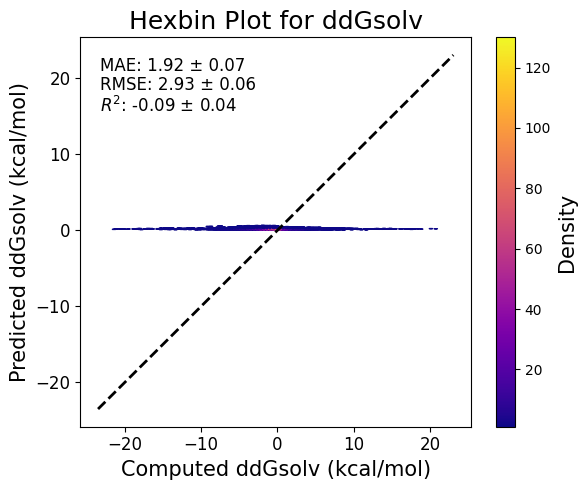

In [ ]:
import numpy as np
# Load the data
df_data = pd.read_csv('rxn_split_fold_0.csv')
df_pred = pd.read_csv('pred_results_rxn_split_fold_0.csv')

# List of target columns to plot
target_types = ['ddGsolv']

# Call the function
parity_plot(df_data, df_pred, target_types)

RETRYING

In [16]:
# Set the path to the model file and arguments
curr_dir = os.getcwd()
model_dir = os.path.join(curr_dir, '../ML_model_files')

# Set the path to the model file and arguments
arguments = [
    '--data_path', 'RxnSolvKSE_dataset_v1.1/finetuning_set/chosen_data/finetuning_rxn_solvent_ddGsolv_ddHsolv_chosen.csv',
    '--dataset_type', 'regression',
    '--save_dir', 'refinetuned_models_2',
    '--epochs', '10',
    '--checkpoint_frzn', 'KSE_ML_model_files/model_0/model.pt',
    '--number_of_molecules', '2',
    '--num_workers', '0',
    '--smiles_columns', 'rxn_smiles', 'solvent_smiles',
    '--empty_cache',
    '--reaction_solvent',
    '--reaction_mode', 'reac_prod',
    '--target_columns', 'ddGsolv'
]

# make predictions
args = chemprop.args.TrainArgs().parse_args(arguments)
mean_score, std_score = chemprop.train.cross_validate(args=args, train_func=chemprop.train.run_training)

Command line
python /Users/abdiwadud/miniconda3/envs/chemprop/lib/python3.8/site-packages/ipykernel_launcher.py --f=/Users/abdiwadud/Library/Jupyter/runtime/kernel-v3382611ee2a0278ae1cde205ded1c688e27f1d962.json
Args
{'activation': 'ReLU',
 'adding_bond_types': True,
 'adding_h': False,
 'aggregation': 'mean',
 'aggregation_norm': 100,
 'atom_constraints': [],
 'atom_descriptor_scaling': True,
 'atom_descriptors': None,
 'atom_descriptors_path': None,
 'atom_descriptors_size': 0,
 'atom_features_size': 0,
 'atom_messages': False,
 'atom_targets': [],
 'batch_size': 50,
 'bias': False,
 'bias_solvent': False,
 'bond_constraints': [],
 'bond_descriptor_scaling': True,
 'bond_descriptors': None,
 'bond_descriptors_path': None,
 'bond_descriptors_size': 0,
 'bond_features_size': 0,
 'bond_targets': [],
 'cache_cutoff': 10000,
 'checkpoint_dir': None,
 'checkpoint_frzn': 'KSE_ML_model_files/model_0/model.pt',
 'checkpoint_path': None,
 'checkpoint_paths': None,
 'class_balance': False,
 'co

Pretrained parameter "('encoder.encoder.0.W_i.weight', 'encoder.encoder.0.W_h.weight', 'encoder.encoder.0.W_o.weight', 'encoder.encoder.0.W_o.bias')" cannot be found in model parameters.
Pretrained parameter "('encoder.encoder.1.W_i.weight', 'encoder.encoder.1.W_h.weight', 'encoder.encoder.1.W_o.weight', 'encoder.encoder.1.W_o.bias')" cannot be found in model parameters.


  0%|          | 0/10 [00:00<?, ?it/s]Epoch 0
Loss = 1.0670e+00, PNorm = 46.3514, GNorm = 1.7290, lr_0 = 1.0672e-04
Loss = 9.7097e-01, PNorm = 46.3522, GNorm = 3.0204, lr_0 = 1.1282e-04
Loss = 9.2650e-01, PNorm = 46.3533, GNorm = 1.0995, lr_0 = 1.1893e-04
Loss = 7.8279e-01, PNorm = 46.3545, GNorm = 1.0426, lr_0 = 1.2503e-04
Loss = 8.0763e-01, PNorm = 46.3559, GNorm = 1.4890, lr_0 = 1.3114e-04
Loss = 7.5048e-01, PNorm = 46.3576, GNorm = 0.7644, lr_0 = 1.3725e-04
Loss = 7.2567e-01, PNorm = 46.3593, GNorm = 2.2933, lr_0 = 1.4335e-04
Loss = 9.3297e-01, PNorm = 46.3616, GNorm = 1.1720, lr_0 = 1.4946e-04
Loss = 9.2806e-01, PNorm = 46.3643, GNorm = 0.6129, lr_0 = 1.5556e-04
Loss = 9.0604e-01, PNorm = 46.3673, GNorm = 2.0342, lr_0 = 1.6167e-04
Loss = 9.5719e-01, PNorm = 46.3713, GNorm = 2.5643, lr_0 = 1.6777e-04
Loss = 8.5717e-01, PNorm = 46.3761, GNorm = 0.9879, lr_0 = 1.7388e-04
Loss = 7.8271e-01, PNorm = 46.3808, GNorm = 1.1254, lr_0 = 1.7999e-04
Loss = 7.7948e-01, PNorm = 46.3865, GNorm = 

In [9]:
# Set the path to the model file and arguments
curr_dir = os.getcwd()
model_dir = os.path.join(curr_dir, '../ML_model_files')

# Set the path to the model file and arguments
arguments = [
    '--test_path', 'rxn_split_fold_0.csv',
    '--preds_path', 'pred_results_rxn_split_finetuned_2.csv',
    '--checkpoint_dir', 'refinetuned_models_2/fold_0/model_0',
    '--number_of_molecules', '2',
    '--num_workers', '0',
    '--smiles_columns', 'rxn_smiles', 'solvent_smiles',
    '--empty_cache',
    '--target_columns', 'ddGsolv'
]


# make predictions
args = chemprop.args.PredictArgs().parse_args(arguments)
preds = chemprop.train.make_predictions(args=args)

usage: ipykernel_launcher.py --test_path TEST_PATH --preds_path PREDS_PATH
                             [--drop_extra_columns] [--ensemble_variance]
                             [--individual_ensemble_predictions]
                             [--uncertainty_method {mve,ensemble,evidential_epistemic,evidential_aleatoric,evidential_total,classification,dropout,spectra_roundrobin,dirichlet}]
                             [--calibration_method {zscaling,tscaling,zelikman_interval,mve_weighting,platt,isotonic,conformal,conformal_adaptive,conformal_regression,conformal_quantile_regression}]
                             [--evaluation_methods [EVALUATION_METHODS [EVALUATION_METHODS ...]]]
                             [--evaluation_scores_path EVALUATION_SCORES_PATH]
                             [--uncertainty_dropout_p UNCERTAINTY_DROPOUT_P]
                             [--conformal_alpha CONFORMAL_ALPHA]
                             [--dropout_sampling_size DROPOUT_SAMPLING_SIZE]
             

SystemExit: 2

/Users/abdiwadud/miniconda3/envs/chemprop/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3516: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


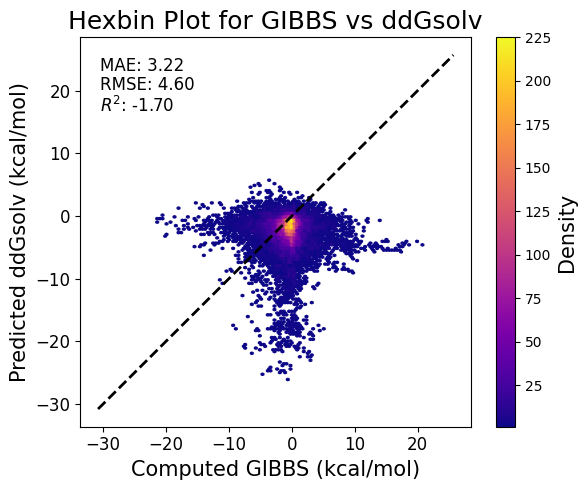

In [20]:
import numpy as np
# Load the data
df_data = pd.read_csv('rxn_split_fold_0.csv')
df_pred = pd.read_csv('pred_results_rxn_split_finetuned_2.csv')

# Call the function
single_parity_plot(df_data, df_pred)

In [3]:
# Set the path to the model file and arguments
curr_dir = os.getcwd()
model_dir = os.path.join(curr_dir, '../ML_model_files')

# Set the path to the model file and arguments
arguments = [
    '--test_path', 'rxn_split_fold_1.csv',
    '--preds_path', 'pred_results_rxn_split_fold_1_finetuned_2.csv',
    '--checkpoint_dir', 'refinetuned_models_2/fold_0/model_0',
    '--number_of_molecules', '2',
    '--num_workers', '0',
    '--smiles_columns', 'rxn_smiles', 'solvent_smiles',
    '--empty_cache'
]


# make predictions
args = chemprop.args.PredictArgs().parse_args(arguments)
preds = chemprop.train.make_predictions(args=args)

/Users/abdiwadud/miniconda3/envs/chemprop/lib/python3.8/site-packages/chemprop/utils.py:472: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vars(torch.load(path, map_location

Loading training args
Setting molecule featurization parameters to default.
Loading data


24297it [00:00, 152251.15it/s]
100%|██████████| 24297/24297 [00:00<00:00, 158445.79it/s]


Validating SMILES


[14:21:45] WARNING: not removing hydrogen atom without neighbors
[14:21:46] WARNING: not removing hydrogen atom without neighbors
[14:21:46] WARNING: not removing hydrogen atom without neighbors
[14:21:46] WARNING: not removing hydrogen atom without neighbors
[14:21:46] WARNING: not removing hydrogen atom without neighbors
[14:21:47] WARNING: not removing hydrogen atom without neighbors


Test size = 24,297


  0%|          | 0/1 [00:00<?, ?it/s]/Users/abdiwadud/miniconda3/envs/chemprop/lib/python3.8/site-packages/chemprop/utils.py:111: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.

Loading pretrained parameter "encoder.encoder.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.W_i.weight".
Loading pretrained parameter "encoder.encoder.W_h.weight".
Loading pretrained parameter "encoder.encoder.W_o.weight".
Loading pretrained parameter "encoder.encoder.W_o.bias".
Loading pretrained parameter "encoder.encoder_solvent.cached_zero_vector".
Loading pretrained parameter "encoder.encoder_solvent.W_i.weight".
Loading pretrained parameter "encoder.encoder_solvent.W_h.weight".
Loading pretrained parameter "encoder.encoder_solvent.W_o.weight".
Loading pretrained parameter "encoder.encoder_solvent.W_o.bias".
Loading pretrained parameter "readout.1.weight".
Loading pretrained parameter "readout.1.bias".
Loading pretrained parameter "readout.4.weight".
Loading pretrained parameter "readout.4.bias".


100%|██████████| 1/1 [00:14<00:00, 14.37s/it]


Saving predictions to pred_results_rxn_split_fold_1_finetuned_2.csv
Elapsed time = 0:00:17


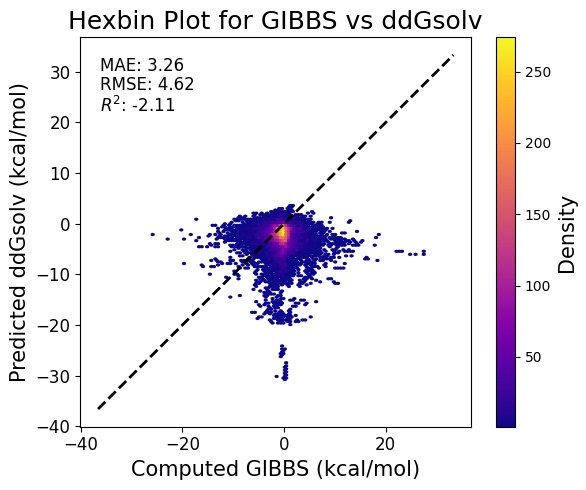

In [7]:
import numpy as np
# Load the data
df_data = pd.read_csv('rxn_split_fold_1.csv')
df_pred = pd.read_csv('pred_results_rxn_split_fold_1_finetuned_2.csv')

# Call the function
single_parity_plot(df_data, df_pred)

In [10]:
# Set the path to the model file and arguments
curr_dir = os.getcwd()
model_dir = os.path.join(curr_dir, '../ML_model_files')

# Set the path to the model file and arguments
arguments = [
    '--test_path', 'rxn_split_fold_2.csv',
    '--preds_path', 'pred_results_rxn_split_fold_2_finetuned_2.csv',
    '--checkpoint_dir', 'refinetuned_models_2/fold_0/model_0',
    '--number_of_molecules', '2',
    '--num_workers', '0',
    '--smiles_columns', 'rxn_smiles', 'solvent_smiles',
    '--empty_cache'
]


# make predictions
args = chemprop.args.PredictArgs().parse_args(arguments)
preds = chemprop.train.make_predictions(args=args)

/Users/abdiwadud/miniconda3/envs/chemprop/lib/python3.8/site-packages/chemprop/utils.py:472: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vars(torch.load(path, map_location

Loading training args
Setting molecule featurization parameters to default.
Loading data


24232it [00:00, 290530.76it/s]
100%|██████████| 24232/24232 [00:00<00:00, 113072.53it/s]
[14:25:35] WARNING: not removing hydrogen atom without neighbors
[14:25:35] WARNING: not removing hydrogen atom without neighbors


Validating SMILES


[14:25:36] WARNING: not removing hydrogen atom without neighbors
[14:25:36] WARNING: not removing hydrogen atom without neighbors


Test size = 24,232


  0%|          | 0/1 [00:00<?, ?it/s]/Users/abdiwadud/miniconda3/envs/chemprop/lib/python3.8/site-packages/chemprop/utils.py:111: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.

Loading pretrained parameter "encoder.encoder.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.W_i.weight".
Loading pretrained parameter "encoder.encoder.W_h.weight".
Loading pretrained parameter "encoder.encoder.W_o.weight".
Loading pretrained parameter "encoder.encoder.W_o.bias".
Loading pretrained parameter "encoder.encoder_solvent.cached_zero_vector".
Loading pretrained parameter "encoder.encoder_solvent.W_i.weight".
Loading pretrained parameter "encoder.encoder_solvent.W_h.weight".
Loading pretrained parameter "encoder.encoder_solvent.W_o.weight".
Loading pretrained parameter "encoder.encoder_solvent.W_o.bias".
Loading pretrained parameter "readout.1.weight".
Loading pretrained parameter "readout.1.bias".
Loading pretrained parameter "readout.4.weight".
Loading pretrained parameter "readout.4.bias".


100%|██████████| 1/1 [00:15<00:00, 15.11s/it]


Saving predictions to pred_results_rxn_split_fold_2_finetuned_2.csv
Elapsed time = 0:00:17


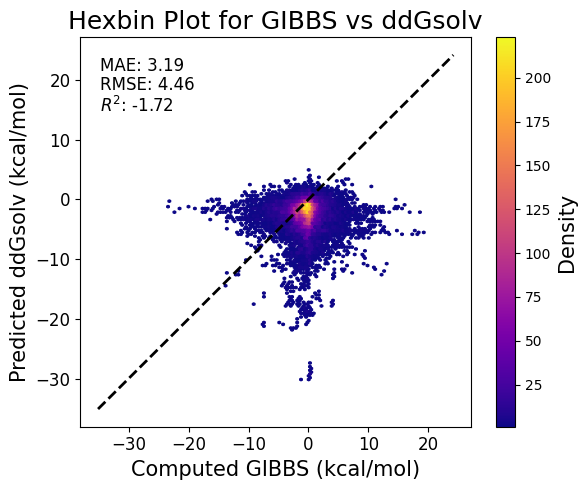

In [11]:
import numpy as np
# Load the data
df_data = pd.read_csv('rxn_split_fold_2.csv')
df_pred = pd.read_csv('pred_results_rxn_split_fold_2_finetuned_2.csv')

# Call the function
single_parity_plot(df_data, df_pred)

In [17]:
# Set the path to the model file and arguments
curr_dir = os.getcwd()
model_dir = os.path.join(curr_dir, '../ML_model_files')

# Set the path to the model file and arguments
arguments = [
    '--test_path', 'rxn_split_fold_3.csv',
    '--preds_path', 'pred_results_rxn_split_fold_3_finetuned_2.csv',
    '--checkpoint_dir', 'refinetuned_models_2/fold_0/model_0',
    '--number_of_molecules', '2',
    '--num_workers', '0',
    '--smiles_columns', 'rxn_smiles', 'solvent_smiles',
    '--empty_cache'
]


# make predictions
args = chemprop.args.PredictArgs().parse_args(arguments)
preds = chemprop.train.make_predictions(args=args)

/Users/abdiwadud/miniconda3/envs/chemprop/lib/python3.8/site-packages/chemprop/utils.py:472: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vars(torch.load(path, map_location

Loading training args
Setting molecule featurization parameters to default.
Loading data


24102it [00:00, 286485.04it/s]
100%|██████████| 24102/24102 [00:00<00:00, 140774.45it/s]


Validating SMILES


[14:27:20] WARNING: not removing hydrogen atom without neighbors
[14:27:20] WARNING: not removing hydrogen atom without neighbors
[14:27:20] WARNING: not removing hydrogen atom without neighbors
[14:27:21] WARNING: not removing hydrogen atom without neighbors
[14:27:21] WARNING: not removing hydrogen atom without neighbors
[14:27:21] WARNING: not removing hydrogen atom without neighbors


Test size = 24,102


  0%|          | 0/1 [00:00<?, ?it/s]/Users/abdiwadud/miniconda3/envs/chemprop/lib/python3.8/site-packages/chemprop/utils.py:111: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.

Loading pretrained parameter "encoder.encoder.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.W_i.weight".
Loading pretrained parameter "encoder.encoder.W_h.weight".
Loading pretrained parameter "encoder.encoder.W_o.weight".
Loading pretrained parameter "encoder.encoder.W_o.bias".
Loading pretrained parameter "encoder.encoder_solvent.cached_zero_vector".
Loading pretrained parameter "encoder.encoder_solvent.W_i.weight".
Loading pretrained parameter "encoder.encoder_solvent.W_h.weight".
Loading pretrained parameter "encoder.encoder_solvent.W_o.weight".
Loading pretrained parameter "encoder.encoder_solvent.W_o.bias".
Loading pretrained parameter "readout.1.weight".
Loading pretrained parameter "readout.1.bias".
Loading pretrained parameter "readout.4.weight".
Loading pretrained parameter "readout.4.bias".


100%|██████████| 1/1 [00:14<00:00, 14.93s/it]


Saving predictions to pred_results_rxn_split_fold_3_finetuned_2.csv
Elapsed time = 0:00:17


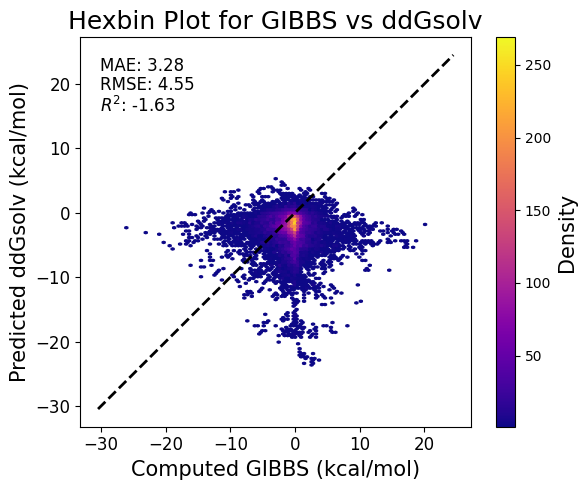

In [13]:
import numpy as np
# Load the data
df_data = pd.read_csv('rxn_split_fold_3.csv')
df_pred = pd.read_csv('pred_results_rxn_split_fold_3_finetuned_2.csv')

# Call the function
single_parity_plot(df_data, df_pred)

In [ ]:
# Set the path to the model file and arguments
curr_dir = os.getcwd()
model_dir = os.path.join(curr_dir, '../ML_model_files')

# Set the path to the model file and arguments
arguments = [
    '--test_path', 'rxn_split_fold_4.csv',
    '--preds_path', 'pred_results_rxn_split_fold_4_finetuned_2.csv',
    '--checkpoint_dir', 'refinetuned_models_2/fold_0/model_0',
    '--number_of_molecules', '2',
    '--num_workers', '0',
    '--smiles_columns', 'rxn_smiles', 'solvent_smiles',
    '--empty_cache'
]


# make predictions
args = chemprop.args.PredictArgs().parse_args(arguments)
preds = chemprop.train.make_predictions(args=args)

Loading training args
Setting molecule featurization parameters to default.
Loading data


24283it [00:00, 159363.43it/s]
100%|██████████| 24283/24283 [00:00<00:00, 142835.10it/s]
[14:27:44] WARNING: not removing hydrogen atom without neighbors


Validating SMILES


[14:27:45] WARNING: not removing hydrogen atom without neighbors
[14:27:45] WARNING: not removing hydrogen atom without neighbors
[14:27:45] WARNING: not removing hydrogen atom without neighbors


Test size = 24,283


  0%|          | 0/1 [00:00<?, ?it/s]

Loading pretrained parameter "encoder.encoder.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.W_i.weight".
Loading pretrained parameter "encoder.encoder.W_h.weight".
Loading pretrained parameter "encoder.encoder.W_o.weight".
Loading pretrained parameter "encoder.encoder.W_o.bias".
Loading pretrained parameter "encoder.encoder_solvent.cached_zero_vector".
Loading pretrained parameter "encoder.encoder_solvent.W_i.weight".
Loading pretrained parameter "encoder.encoder_solvent.W_h.weight".
Loading pretrained parameter "encoder.encoder_solvent.W_o.weight".
Loading pretrained parameter "encoder.encoder_solvent.W_o.bias".
Loading pretrained parameter "readout.1.weight".
Loading pretrained parameter "readout.1.bias".
Loading pretrained parameter "readout.4.weight".
Loading pretrained parameter "readout.4.bias".


100%|██████████| 1/1 [00:14<00:00, 14.38s/it]


Saving predictions to pred_results_rxn_split_fold_4_finetuned_2.csv
Elapsed time = 0:00:17


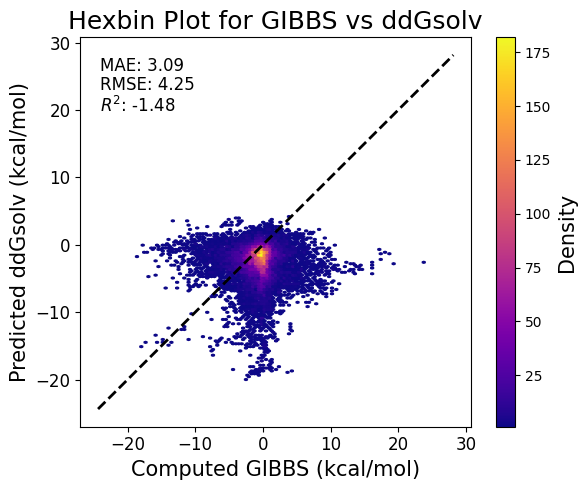

In [19]:
import numpy as np
# Load the data
df_data = pd.read_csv('rxn_split_fold_4.csv')
df_pred = pd.read_csv('pred_results_rxn_split_fold_4_finetuned_2.csv')

# Call the function
single_parity_plot(df_data, df_pred)

In [ ]:
# Set the path to the model file and arguments
curr_dir = os.getcwd()
model_dir = os.path.join(curr_dir, '../ML_model_files')

# Set the path to the model file and arguments
arguments = [
    '--data_path', 'RxnSolvKSE_dataset_v1.1/finetuning_set/chosen_data/finetuning_rxn_solvent_ddGsolv_ddHsolv_chosen.csv',
    '--dataset_type', 'regression',
    '--save_dir', 'refinetuned_models_3',
    '--epochs', '10',
    '--checkpoint_frzn', 'KSE_ML_model_files/model_0/model.pt',
    '--number_of_molecules', '2',
    '--num_workers', '0',
    '--smiles_columns', 'rxn_smiles', 'solvent_smiles',
    '--empty_cache',
    '--reaction_solvent',
    '--reaction_mode', 'reac_prod',
    '--target_columns', 'ddGsolv'
]

# make predictions
args = chemprop.args.TrainArgs().parse_args(arguments)
mean_score, std_score = chemprop.train.cross_validate(args=args, train_func=chemprop.train.run_training)

usage: ipykernel_launcher.py --data_path DATA_PATH
                             [--target_columns [TARGET_COLUMNS [TARGET_COLUMNS ...]]]
                             [--ignore_columns [IGNORE_COLUMNS [IGNORE_COLUMNS ...]]]
                             --dataset_type
                             {regression,classification,multiclass,spectra}
                             [--loss_function {mse,bounded_mse,binary_cross_entropy,cross_entropy,mcc,sid,wasserstein,mve,evidential,dirichlet,quantile_interval}]
                             [--multiclass_num_classes MULTICLASS_NUM_CLASSES]
                             [--separate_val_path SEPARATE_VAL_PATH]
                             [--separate_test_path SEPARATE_TEST_PATH]
                             [--spectra_phase_mask_path SPECTRA_PHASE_MASK_PATH]
                             [--data_weights_path DATA_WEIGHTS_PATH]
                             [--target_weights [TARGET_WEIGHTS [TARGET_WEIGHTS ...]]]
                             [--split_t

SystemExit: 2

/Users/abdiwadud/miniconda3/envs/chemprop/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3516: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
# Set the path to the model file and arguments
curr_dir = os.getcwd()
model_dir = os.path.join(curr_dir, '../ML_model_files')

# Set the path to the model file and arguments
arguments = [
    '--data_path', 'fine_tuning_example.csv',
    '--dataset_type', 'regression',
    '--save_dir', 'refinetuned_models_4',
    '--epochs', '10',
    '--checkpoint_frzn', 'KSE_ML_model_files/model_0/model.pt',
    'KSE_ML_model_files/model_1/model.pt',
    'KSE_ML_model_files/model_2/model.pt',
    'KSE_ML_model_files/model_3/model.pt',
    'KSE_ML_model_files/model_4/model.pt',
    'KSE_ML_model_files/model_5/model.pt',
    'KSE_ML_model_files/model_6/model.pt',
    'KSE_ML_model_files/model_7/model.pt',
    'KSE_ML_model_files/model_8/model.pt',
    'KSE_ML_model_files/model_9/model.pt',
    'KSE_ML_model_files/model_10/model.pt',
    'KSE_ML_model_files/model_11/model.pt',
    'KSE_ML_model_files/model_12/model.pt',
    'KSE_ML_model_files/model_13/model.pt',
    'KSE_ML_model_files/model_14/model.pt',
    'KSE_ML_model_files/model_15/model.pt',
    'KSE_ML_model_files/model_16/model.pt',
    'KSE_ML_model_files/model_17/model.pt',
    'KSE_ML_model_files/model_18/model.pt',
    'KSE_ML_model_files/model_19/model.pt',
    'KSE_ML_model_files/model_20/model.pt',
    'KSE_ML_model_files/model_21/model.pt',
    'KSE_ML_model_files/model_22/model.pt',
    'KSE_ML_model_files/model_23/model.pt',
    'KSE_ML_model_files/model_24/model.pt',

    '--number_of_molecules', '2',
    '--num_workers', '0',
    '--smiles_columns', 'rxn_smiles', 'solvent_smiles',
    '--empty_cache',
    '--reaction_solvent',
    '--reaction_mode', 'reac_prod',
    '--target_columns', 'ddGsolv',
    '--batch_size', '30',
    '--hidden_size', '400',
    '--ffn_hidden_size', '900',
    '--depth', '4',
    '--warmup_epochs', '4',
    '--init_lr', '1.8e-4',
    '--max_lr', '2.2e-4',
    '--final_lr', '5.2e-5',
    '--aggregation', 'norm'
]

# make predictions
args = chemprop.args.TrainArgs().parse_args(arguments)
mean_score, std_score = chemprop.train.cross_validate(args=args, train_func=chemprop.train.run_training)


Command line
python /Users/abdiwadud/miniconda3/envs/chemprop/lib/python3.8/site-packages/ipykernel_launcher.py --f=/Users/abdiwadud/Library/Jupyter/runtime/kernel-v3caaaeb6824dc7d92d7f9f4bced57c65c86ee0780.json
Args
{'activation': 'ReLU',
 'adding_bond_types': True,
 'adding_h': False,
 'aggregation': 'norm',
 'aggregation_norm': 100,
 'atom_constraints': [],
 'atom_descriptor_scaling': True,
 'atom_descriptors': None,
 'atom_descriptors_path': None,
 'atom_descriptors_size': 0,
 'atom_features_size': 0,
 'atom_messages': False,
 'atom_targets': [],
 'batch_size': 30,
 'bias': False,
 'bias_solvent': False,
 'bond_constraints': [],
 'bond_descriptor_scaling': True,
 'bond_descriptors': None,
 'bond_descriptors_path': None,
 'bond_descriptors_size': 0,
 'bond_features_size': 0,
 'bond_targets': [],
 'cache_cutoff': 10000,
 'checkpoint_dir': None,
 'checkpoint_frzn': 'KSE_ML_model_files/model_{i}/model.pt',
 'checkpoint_path': None,
 'checkpoint_paths': None,
 'class_balance': False,
 '

FileNotFoundError: [Errno 2] No such file or directory: 'KSE_ML_model_files/model_{i}/model.pt'

In [11]:
# Set the path to the model file and arguments
curr_dir = os.getcwd()
model_dir = os.path.join(curr_dir, '../ML_model_files')

# Set the path to the model file and arguments
arguments = [
    '--test_path', 'rxn_split_fold_0.csv',
    '--preds_path', 'pred_results_rxn_split_fold_0_finetuned_3.csv',
    '--checkpoint_dir', 'refinetuned_models_3/fold_0/model_0',
    '--number_of_molecules', '2',
    '--num_workers', '0',
    '--smiles_columns', 'rxn_smiles', 'solvent_smiles',
    '--empty_cache'
]


# make predictions
args = chemprop.args.PredictArgs().parse_args(arguments)
preds = chemprop.train.make_predictions(args=args)

/Users/abdiwadud/miniconda3/envs/chemprop/lib/python3.8/site-packages/chemprop/utils.py:472: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vars(torch.load(path, map_location

Loading training args
Setting molecule featurization parameters to default.
Loading data


24213it [00:00, 63865.14it/s]
100%|██████████| 24213/24213 [00:00<00:00, 244284.02it/s]
[16:24:24] WARNING: not removing hydrogen atom without neighbors


Validating SMILES


[16:24:25] WARNING: not removing hydrogen atom without neighbors


Test size = 24,213


  0%|          | 0/1 [00:00<?, ?it/s]/Users/abdiwadud/miniconda3/envs/chemprop/lib/python3.8/site-packages/chemprop/utils.py:111: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.

100%|██████████| 1/1 [00:22<00:00, 22.23s/it]


Saving predictions to pred_results_rxn_split_fold_0_finetuned_3.csv
Elapsed time = 0:00:25


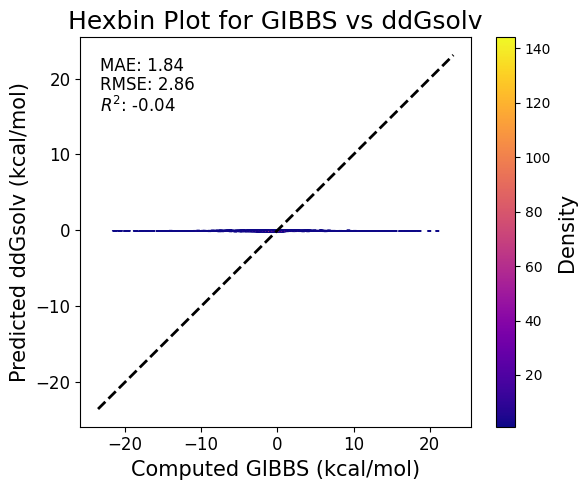

In [12]:
import numpy as np
# Load the data
df_data = pd.read_csv('rxn_split_fold_0.csv')
df_pred = pd.read_csv('pred_results_rxn_split_fold_0_finetuned_3.csv')

# Call the function
single_parity_plot(df_data, df_pred)